In [1]:
import pandas as pd
import numpy as np
import datetime as dt
import scipy
import matplotlib.pyplot as plt
import seaborn as sns
import meteostat
import pickle
import upsetplot

In [2]:
def calculate_shannon_diversity_from_proportions(abundance_array):
    """Calculate Shannon diversity index from an array of proportions."""
    # Filter out zero proportions to avoid log(0)
    filtered_abundance = abundance_array[abundance_array > 0]
    shannon_index = -np.sum(filtered_abundance * np.log(filtered_abundance))
    return shannon_index

In [3]:
transcriptome = pd.read_csv(
    "/Users/michael/Data/Luke_terrace_experiment/General_data/plate1_5_tpm_normalized.csv",
    index_col=0,
)
rows_to_drop_expression_data = [
    "A2450525897_n01_undetermined",
    "A2449446903_n01_undetermined",
    "B250508004_n01_undetermined",
    "B2449500127_n01_undetermined",
]
transcriptome = transcriptome.drop(index=rows_to_drop_expression_data)
transcriptome = transcriptome.sort_index()
metadata = pd.read_csv(
    "/Users/michael/Data/Luke_terrace_experiment/General_data/Plates_1_to_5_metadata_merged_luke.csv",
    index_col=0,
)
metadata = metadata.drop(
    columns=[
        "arb.sort",
        "sample-id",
        "Ambiguous Unstranded",
        "Ambiguous Forward",
        "Multimapping",
        "Unmapped Over Mapped",
    ]
)
metadata["Date and Time"] = metadata["date"] + " " + metadata["time"]
luke_time_data_format = "%-m/%-d/%y %-H:%-M"
metadata["Date and Time"] = pd.to_datetime(
    metadata["Date and Time"], format=luke_time_data_format
)
unusable_samples = [
    "A2450525897_n01_LICRNA01_A06",
    "A2450525897_n01_LICRNA01_A08",
    "A2450525897_n01_LICRNA01_C11",
    "A2450525897_n01_LICRNA01_D11",
    "A2450525897_n01_LICRNA01_D12",
    "A2449446903_n01_LICRNA02_F01",
    "B2449500127_n01_LICRNA04_A04",
    "B2449500127_n01_LICRNA04_A06",
    "B2449500127_n01_LICRNA04_A07",
]
borderline_unusable = [
    "A2450525897_n01_LICRNA01_F03",
    "A2450525897_n01_LICRNA01_G07",
    "A2449446903_n01_LICRNA02_A04",
    "A2449446903_n01_LICRNA02_H10",
    "B2449500127_n01_LICRNA04_H02",
    "B2449500127_n01_LICRNA04_H11",
]
all_unsable = borderline_unusable + unusable_samples
# trimmed_transcriptome = transcriptome.drop(index=all_unsable)
# trimmed_metadata = metadata.drop(index=all_unsable)
## Get plate 5 samples and remove what they replaced from the metadata to avoid duplicates
plate_5_replacements = metadata.loc[metadata["rnaprepplate"] == "LICRNA_05"]
non_plate_5_samples = metadata.loc[metadata["rnaprepplate"] != "LICRNA_05"]
replaced_samples = non_plate_5_samples.loc[
    non_plate_5_samples["sampID"].isin(plate_5_replacements["sampID"])
]
trimmed_metadata = metadata.drop(index=replaced_samples.index)
### get duplicates and drop the one with higher total genes, so that we can drop everything from the main list
double_duplicates = (
    trimmed_metadata.loc[
        trimmed_metadata.duplicated(
            subset="sampID",
            keep=False,
        )
    ]
    .sort_values(by="Total Reads")
    .drop_duplicates(subset="sampID", keep="first")
)
trimmed_metadata = trimmed_metadata.drop(index=double_duplicates.index)
trimmed_metadata
trimmed_transcriptome = transcriptome.loc[trimmed_metadata.index]
trimmed_transcriptome

,AT1G01010,AT1G01020,AT1G03987,AT1G01030,AT1G01040,AT1G03993,AT1G01046,AT1G01050,AT1G03997,AT1G01060,...,ArthCt124,ArthCr088,ArthCt112,ArthCp088,ArthCp086,ArthCt118,ArthCp083,ArthCt111,ArthCp084,ArthCp085
filename,,,,,,,,,,,,,,,,,,,,,
A2450525897_n01_LICRNA01_A01,4.944011,1.397952,0.0,5.994827,5.876072,0.0,0.0,58.062147,0.0,15.150509,...,0.000000,13.256631,0.000000,0.938539,0.0,0.0,0.956942,0.0,0.000000,1.597223
A2450525897_n01_LICRNA01_B01,2.911492,4.379655,0.0,2.665837,3.261267,0.0,0.0,57.934612,0.0,10.439273,...,0.000000,13.734068,0.000000,0.350043,0.0,0.0,0.166556,0.0,0.000000,2.184266
A2450525897_n01_LICRNA01_C01,6.270921,9.657724,0.0,0.000000,4.158376,0.0,0.0,38.161651,0.0,10.623477,...,34.304262,31.001035,0.000000,0.000000,0.0,0.0,0.051248,0.0,0.000000,0.855379
A2450525897_n01_LICRNA01_E01,3.690795,5.635420,0.0,3.786748,2.141076,0.0,0.0,37.996762,0.0,8.530523,...,0.000000,9.676399,0.000000,0.000000,0.0,0.0,0.142875,0.0,0.000000,1.987260
A2450525897_n01_LICRNA01_F01,2.781737,8.695001,0.0,2.016710,8.565957,0.0,0.0,64.854957,0.0,16.845214,...,0.000000,67.280011,0.000000,0.000000,0.0,0.0,0.496000,0.0,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
A2534491401_n01_LICRNA05_D12,0.000000,8.339930,0.0,7.860235,3.199519,0.0,0.0,39.201659,0.0,1.057777,...,0.000000,4.602930,22.529946,1.333133,0.0,0.0,0.036247,0.0,4.867353,5.293749
A2534491401_n01_LICRNA05_E12,0.000000,1.692107,0.0,1.577446,3.055581,0.0,0.0,29.564231,0.0,12.872063,...,0.000000,6.899039,1.605254,3.951394,0.0,0.0,0.839348,0.0,0.000000,3.222183
A2534491401_n01_LICRNA05_F12,0.641335,5.972190,0.0,1.641699,5.632121,0.0,0.0,48.940407,0.0,24.612749,...,0.000000,7.502750,0.000000,1.799150,0.0,0.0,0.000000,0.0,0.000000,0.145801


In [4]:
total_load_df = pd.read_csv(
    "/Users/michael/Data/Luke_terrace_experiment/Microbiome/lic2024_ham_16S_ITS.csv",
    index_col=0,
)

long_term_metadata_w_load_info = trimmed_metadata.merge(
    total_load_df[["ham16s", "giitsreads", "hamits"]],
    left_on="sampID",
    right_index=True,
    how="left",
)

In [5]:
long_term_transcriptome = trimmed_transcriptome.loc[
    trimmed_metadata["Experiment Type"] == "Long Term"
]
long_term_metadata = trimmed_metadata.loc[
    trimmed_metadata["Experiment Type"] == "Long Term"
]

In [6]:
groupby_timepoint = long_term_transcriptome.groupby(
    long_term_metadata["timepoint"]
).mean()
# groupby_timepoint = groupby_timepoint.loc[:, (groupby_timepoint  == 0).mean() < .5] ## At least half of timepoints are non zero (slighlty unintuitive because ==0 makes zeros 1)
groupby_timepoint = groupby_timepoint.loc[
    :, (groupby_timepoint > 1).mean() > 0.5
]  ## At least half of timepoints bigger than 1
groupby_timepoint

,AT1G01020,AT1G01030,AT1G01040,AT1G01050,AT1G01060,AT1G01070,AT1G01080,AT1G01090,AT1G01100,AT1G01120,...,ArthCt115,ArthCr091,ArthCr090,ArthCr089,ArthCt114,ArthCt124,ArthCr088,ArthCt112,ArthCp088,ArthCp085
timepoint,,,,,,,,,,,,,,,,,,,,,
t01,4.695736,3.214951,4.659118,45.511494,10.074553,0.848673,9.911073,64.952874,1220.587817,116.812629,...,5.059142,2.266853,38.067473,124.135253,5.129458,6.651848,25.063342,0.000000,0.161073,1.349695
t02,8.521487,3.802755,4.614660,24.535971,42.409785,0.807000,12.805762,76.692153,814.987884,107.148983,...,0.000000,1.165736,8.205192,153.990699,2.898370,0.244885,17.616390,3.428396,0.037675,1.199569
t03,8.938611,3.626504,3.839474,53.054812,30.863534,3.037648,7.541376,72.182021,923.606197,97.751440,...,0.000000,0.000000,16.550298,79.893367,5.117151,0.906146,14.299652,0.000000,1.886578,0.850575
t04,7.674816,5.922081,5.006461,28.959007,39.972919,1.555315,13.910990,76.747498,1193.770144,125.819497,...,0.000000,2.551425,6.978923,80.358859,0.000000,3.078758,19.860159,4.717444,4.191593,2.531536
t05,7.231658,2.810596,3.408045,39.210055,9.475274,0.867596,8.673751,71.087818,1197.611757,90.440264,...,1.585753,10.507572,12.207156,54.827018,1.072475,3.691827,11.660663,8.562370,1.142433,1.981225
t06,5.253688,3.250124,2.521163,34.833778,8.495871,2.079430,13.943191,53.289768,1197.345210,57.455974,...,0.781353,3.864935,13.139310,32.076777,11.785225,6.437508,6.727044,1.132530,3.179569,1.415137
t07,5.538506,1.599549,3.369034,45.930576,6.346635,1.476035,10.868984,66.710874,1121.816801,116.849493,...,1.005183,8.422009,29.999233,51.043823,4.231647,4.238322,10.553173,1.656561,2.898265,1.934121
t08,4.034252,1.315234,2.412136,37.309378,12.520038,0.617279,11.512825,46.354285,540.282869,60.106088,...,2.029913,5.147805,18.927096,76.691200,10.530133,7.631265,6.334308,3.134487,4.265254,2.934250
t09,6.738885,2.113535,2.972460,37.400945,4.794852,1.356576,8.547718,45.746250,722.769467,80.013551,...,4.980713,11.600905,7.845675,38.319131,10.111116,8.889132,6.199668,1.753170,3.384687,2.130671


In [7]:
microbiome_abundance = pd.read_csv(
    "/Users/michael/Data/Luke_terrace_experiment/Microbiome/lic2024_16S_rab.csv"
)
long_term_microbiome = microbiome_abundance.merge(
    metadata[["sampID", "Experiment Type"]], left_on="plantID", right_on="sampID"
)
long_term_microbiome = long_term_microbiome.loc[
    long_term_microbiome["Experiment Type"] == "Long Term"
]
long_term_microbiome

,Sample,sample.type,timepoint,date,time,platename,daysincestart,plantID,Kingdom,Phylum,Class,Order,Family,Genus,Species,AbundR100,sampID,Experiment Type
1,LIC063,plant,t06,11/28/23,8:00,LIC_01,27,LIC063,d__Bacteria,Pseudomonadota,Alphaproteobacteria,Sphingomonadales,Sphingomonadaceae_486827,Sphingomonas_L_486704,Sphingomonas_L_486704 sp000786205,66.1,LIC063,Long Term
2,LIC159,plant,t14,1/23/24,8:00,LIC_02,83,LIC159,d__Bacteria,Cyanobacteriota,Cyanobacteriia,Cyanobacteriales,Coleofasciculaceae,Caldora,Caldora sp010672925,60.5,LIC159,Long Term
5,LIC306,plant,t26,3/8/24,8:00,LIC_04,128,LIC306,d__Bacteria,Pseudomonadota,Alphaproteobacteria,Sphingomonadales,Sphingomonadaceae_486827,Sphingomonas_L_486704,Sphingomonas_L_486704 sp000786205,57.2,LIC306,Long Term
6,LIC016,plant,t02,11/7/23,8:00,LIC_01,6,LIC016,d__Bacteria,Pseudomonadota,Alphaproteobacteria,Sphingomonadales,Sphingomonadaceae_486827,Sphingomonas_L_486704,Sphingomonas_L_486704 sp000786205,54.4,LIC016,Long Term
10,LIC051,plant,t05,11/21/23,8:00,LIC_01,20,LIC051,d__Bacteria,Pseudomonadota,Alphaproteobacteria,Rhizobiales_505101,Rhizobiaceae,Neorhizobium_500197,Neorhizobium soli,49.7,LIC051,Long Term
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15322,LIC157,plant,t14,1/23/24,8:00,LIC_02,83,LIC157,d__Bacteria,Actinomycetota,Actinomycetes,Propionibacteriales,Propionibacteriaceae,Friedmanniella,Friedmanniella luteola,0.5,LIC157,Long Term
15324,LIC195,plant,t17,2/2/24,8:00,LIC_03,93,LIC195,d__Bacteria,Actinomycetota,Actinomycetes,Propionibacteriales,Propionibacteriaceae,Friedmanniella,Friedmanniella flava,0.5,LIC195,Long Term
15325,LIC122,plant,t11,12/15/23,8:00,LIC_02,44,LIC122,d__Bacteria,Actinomycetota,Actinomycetes,Propionibacteriales,Nocardioidaceae,Nocardioides_A_392796,Nocardioides_A_392796 hankookensis,0.5,LIC122,Long Term
15326,LIC028,plant,t03,11/14/23,8:00,LIC_01,13,LIC028,d__Bacteria,Actinomycetota,Actinomycetes,Mycobacteriales,Geodermatophilaceae,Modestobacter,Modestobacter muralis,0.5,LIC028,Long Term


In [8]:
long_term_microbiome.loc[long_term_microbiome["Sample"] == "LIC063"]

,Sample,sample.type,timepoint,date,time,platename,daysincestart,plantID,Kingdom,Phylum,Class,Order,Family,Genus,Species,AbundR100,sampID,Experiment Type
1,LIC063,plant,t06,11/28/23,8:00,LIC_01,27,LIC063,d__Bacteria,Pseudomonadota,Alphaproteobacteria,Sphingomonadales,Sphingomonadaceae_486827,Sphingomonas_L_486704,Sphingomonas_L_486704 sp000786205,66.1,LIC063,Long Term
3758,LIC063,plant,t06,11/28/23,8:00,LIC_01,27,LIC063,d__Bacteria,Actinomycetota,Actinomycetes,Propionibacteriales,Nocardioidaceae,Nocardioides_A_392796,Nocardioides_A_392796 dongxiaopingii,2.6,LIC063,Long Term
4017,LIC063,plant,t06,11/28/23,8:00,LIC_01,27,LIC063,d__Bacteria,Actinomycetota,Actinomycetes,Mycobacteriales,Pseudonocardiaceae,Actinomycetospora,Actinomycetospora chiangmaiensis,2.4,LIC063,Long Term
4125,LIC063,plant,t06,11/28/23,8:00,LIC_01,27,LIC063,d__Bacteria,Pseudomonadota,Alphaproteobacteria,Sphingomonadales,Kordiimonadaceae,Kordiimonas,Kordiimonas sp002401685,2.3,LIC063,Long Term
4389,LIC063,plant,t06,11/28/23,8:00,LIC_01,27,LIC063,d__Bacteria,Actinomycetota,Actinomycetes,Mycobacteriales,Geodermatophilaceae,Klenkia,Klenkia sp001424455,2.2,LIC063,Long Term
5597,LIC063,plant,t06,11/28/23,8:00,LIC_01,27,LIC063,d__Bacteria,Pseudomonadota,Gammaproteobacteria,Pseudomonadales_A_650611,Pseudomonadaceae,Pseudomonas_E_647464,Pseudomonas_E_647464 avellanae,1.6,LIC063,Long Term
5690,LIC063,plant,t06,11/28/23,8:00,LIC_01,27,LIC063,d__Bacteria,Pseudomonadota,Alphaproteobacteria,Sphingomonadales,Sphingomonadaceae_486827,Sphingomonas_L_486704,Sphingomonas_L_486704 yunnanensis,1.6,LIC063,Long Term
6611,LIC063,plant,t06,11/28/23,8:00,LIC_01,27,LIC063,d__Bacteria,Pseudomonadota,Alphaproteobacteria,Rhizobiales_505101,Rhizobiaceae,Neorhizobium_500197,Neorhizobium soli,1.3,LIC063,Long Term
6755,LIC063,plant,t06,11/28/23,8:00,LIC_01,27,LIC063,d__Bacteria,Actinomycetota,Actinomycetes,Actinomycetales,Microbacteriaceae,Microbacterium_A_383321,Microbacterium_A_383321 sp000333395,1.3,LIC063,Long Term
7021,LIC063,plant,t06,11/28/23,8:00,LIC_01,27,LIC063,d__Bacteria,Actinomycetota,Actinomycetes,Propionibacteriales,Nocardioidaceae,Nocardioides_A_392796,Nocardioides_A_392796 halotolerans,1.2,LIC063,Long Term


In [9]:
genus_sum = (
    long_term_microbiome[["Sample", "Genus", "AbundR100"]]
    .groupby(["Sample", "Genus"])
    .sum()
)
genus_sum = genus_sum.reset_index()

genus_sum_w_tp = genus_sum.merge(
    metadata[["sampID", "timepoint"]], left_on="Sample", right_on="sampID"
)
genus_sum_w_tp

,Sample,Genus,AbundR100,sampID,timepoint
0,LIC001,Actinomycetospora,0.6,LIC001,t01
1,LIC001,Actinoplanes,1.1,LIC001,t01
2,LIC001,Aeromicrobium,0.8,LIC001,t01
3,LIC001,Blastococcus,1.7,LIC001,t01
4,LIC001,Caulobacter_487784,0.5,LIC001,t01
...,...,...,...,...,...
5582,LIC368,Pseudoduganella_570666,0.5,LIC368,t08
5583,LIC368,Pseudomonas_E_647464,2.6,LIC368,t08
5584,LIC368,Rhodoferax_C,6.6,LIC368,t08
5585,LIC368,Sphingomonas_L_486704,19.7,LIC368,t08


In [10]:
genus_sum.set_index(
    "Sample",
    drop=True,
).index.difference(
    genus_sum_w_tp.set_index("Sample", drop=True).index
)  ## Difference is from the dropped samples (due to low quality RNA) which we dont' wanna drop here cause its DNA

Index([], dtype='object', name='Sample')

In [11]:
genus_sum_w_tp.head(40)

,Sample,Genus,AbundR100,sampID,timepoint
0,LIC001,Actinomycetospora,0.6,LIC001,t01
1,LIC001,Actinoplanes,1.1,LIC001,t01
2,LIC001,Aeromicrobium,0.8,LIC001,t01
3,LIC001,Blastococcus,1.7,LIC001,t01
4,LIC001,Caulobacter_487784,0.5,LIC001,t01
5,LIC001,Chryseobacterium_A_796612,0.6,LIC001,t01
6,LIC001,Curtobacterium,1.0,LIC001,t01
7,LIC001,Dactylopiibacterium,0.7,LIC001,t01
8,LIC001,Flavobacterium,0.8,LIC001,t01
9,LIC001,Friedmanniella,2.7,LIC001,t01


In [12]:
all_present_genus = genus_sum_w_tp["Genus"].unique()
all_present_genus

array(['Actinomycetospora', 'Actinoplanes', 'Aeromicrobium',
       'Blastococcus', 'Caulobacter_487784', 'Chryseobacterium_A_796612',
       'Curtobacterium', 'Dactylopiibacterium', 'Flavobacterium',
       'Friedmanniella', 'Frigoribacterium', 'Geodermatophilus',
       'Herbaspirillum', 'Hylemonella', 'Kineococcus', 'Kineosporia',
       'Klenkia', 'Kordiimonas', 'Massilia_574544', 'Methylobacterium',
       'Methylophilus', 'Microbacterium_A_383321', 'Nakamurella',
       'Neorhizobium_500197', 'Nocardioides_A_392796',
       'Pseudoduganella_570666', 'Pseudomonas_B_650453',
       'Pseudomonas_E_647464', 'Pseudomonas_E_647626', 'Rhodoferax_C',
       'Solirubrobacter', 'Sphingomonas_L_486704', 'Telluria_573210',
       'Variovorax', 'Arthrobacter_E_385446', 'Arthrobacter_E_385777',
       'Caballeronia', 'Marmoricola_A_392027', 'Massilia_574424',
       'Microlunatus_B', 'Nocardioides_A_392805',
       'Noviherbaspirillum_A_568106', 'Paucimonas', 'Pedococcus',
       'Pseudodugane

In [13]:
genus_sum_w_tp

,Sample,Genus,AbundR100,sampID,timepoint
0,LIC001,Actinomycetospora,0.6,LIC001,t01
1,LIC001,Actinoplanes,1.1,LIC001,t01
2,LIC001,Aeromicrobium,0.8,LIC001,t01
3,LIC001,Blastococcus,1.7,LIC001,t01
4,LIC001,Caulobacter_487784,0.5,LIC001,t01
...,...,...,...,...,...
5582,LIC368,Pseudoduganella_570666,0.5,LIC368,t08
5583,LIC368,Pseudomonas_E_647464,2.6,LIC368,t08
5584,LIC368,Rhodoferax_C,6.6,LIC368,t08
5585,LIC368,Sphingomonas_L_486704,19.7,LIC368,t08


In [14]:
## Need to fill in missing genus in every sample first
for sampID in genus_sum_w_tp["sampID"].unique():
    sampid_only_df = genus_sum_w_tp.loc[genus_sum_w_tp["sampID"] == sampID]
    present_genus_in_samp = sampid_only_df["Genus"].unique()
    difference_in_present_bacteria = list(
        set(all_present_genus) - set(present_genus_in_samp)
    )
    current_time_point = sampid_only_df["timepoint"].iloc[0]
    empty_df_to_add = pd.DataFrame(
        columns=["Sample", "Genus", "AbundR100", "sampID", "timepoint"]
    )
    empty_df_to_add["Genus"] = difference_in_present_bacteria
    empty_df_to_add["Sample"] = sampID
    empty_df_to_add["AbundR100"] = 0
    empty_df_to_add["sampID"] = sampID
    empty_df_to_add["timepoint"] = current_time_point
    genus_sum_w_tp = pd.concat([genus_sum_w_tp, empty_df_to_add])

In [15]:
genus_sum_w_tp

,Sample,Genus,AbundR100,sampID,timepoint
0,LIC001,Actinomycetospora,0.6,LIC001,t01
1,LIC001,Actinoplanes,1.1,LIC001,t01
2,LIC001,Aeromicrobium,0.8,LIC001,t01
3,LIC001,Blastococcus,1.7,LIC001,t01
4,LIC001,Caulobacter_487784,0.5,LIC001,t01
...,...,...,...,...,...
109,LIC368,Telluria_573210,0.0,LIC368,t08
110,LIC368,Pseudokineococcus,0.0,LIC368,t08
111,LIC368,Curvibacter_587305,0.0,LIC368,t08
112,LIC368,Roseateles_592282,0.0,LIC368,t08


In [16]:
timepoint_average_abundance = (
    genus_sum_w_tp[["Genus", "timepoint", "AbundR100"]]
    .groupby(["Genus", "timepoint"])
    .mean()
)
timepoint_average_abundance = timepoint_average_abundance.reset_index()
timepoint_average_abundance

,Genus,timepoint,AbundR100
0,Abditibacterium,t01,0.0
1,Abditibacterium,t02,0.0
2,Abditibacterium,t03,0.0
3,Abditibacterium,t04,0.0
4,Abditibacterium,t05,0.0
...,...,...,...
3831,Xenophilus_587940,t24,0.0
3832,Xenophilus_587940,t25,0.0
3833,Xenophilus_587940,t26,0.0
3834,Xenophilus_587940,t27,0.0


In [17]:
timepoint_cleaned_average_abundance = timepoint_average_abundance.copy()

In [18]:
for genus in timepoint_cleaned_average_abundance["Genus"].unique():
    genus_df = timepoint_cleaned_average_abundance.loc[
        timepoint_cleaned_average_abundance["Genus"] == genus
    ]
    if sum(genus_df["AbundR100"] > 0) < 10:
        timepoint_cleaned_average_abundance = timepoint_cleaned_average_abundance.loc[
            timepoint_cleaned_average_abundance["Genus"] != genus
        ]

In [19]:
timepoint_all_species_abundance = timepoint_average_abundance.copy()

In [20]:
timepoint_cleaned_average_abundance

,Genus,timepoint,AbundR100
84,Actinomycetospora,t01,0.933333
85,Actinomycetospora,t02,1.430000
86,Actinomycetospora,t03,0.700000
87,Actinomycetospora,t04,0.300000
88,Actinomycetospora,t05,0.337500
...,...,...,...
3747,Variovorax,t24,4.555556
3748,Variovorax,t25,7.763636
3749,Variovorax,t26,3.750000
3750,Variovorax,t27,4.112500


In [21]:
# sns.scatterplot(data = timepoint_average_abundance, x = 'timepoint', y = 'AbundR100',)

In [22]:
timepoint_abundance_matrix = pd.pivot_table(
    timepoint_cleaned_average_abundance,
    values="AbundR100",
    index="timepoint",
    columns="Genus",
)
timepoint_abundance_matrix

Genus,Actinomycetospora,Actinoplanes,Aeromicrobium,Aetherobacter,Agrobacterium,Amnibacterium_382409,Aquabacterium_A_592457,Aureimonas_A_501549,Blastococcus,Brevundimonas,...,Pseudomonas_E_647464,Pseudonocardia,Ramlibacter_588642,Rathayibacter,Rhodoferax_C,Rugamonas_570800,Solirubrobacter,Sphingomonas_L_486704,Telluria_573210,Variovorax
timepoint,,,,,,,,,,,,,,,,,,,,,
t01,0.933333,0.137500,0.787500,0.000000,0.000000,0.062500,0.322222,1.840000,0.662500,1.775000,...,3.260000,0.000000,1.577778,0.222222,3.880000,0.225000,0.362500,42.840000,1.755556,3.630000
t02,1.430000,1.470000,0.477778,0.000000,0.622222,0.112500,0.600000,0.311111,2.177778,0.480000,...,5.600000,0.588889,0.000000,0.062500,5.109091,0.933333,0.822222,50.154545,3.700000,1.400000
t03,0.700000,0.600000,0.150000,0.000000,0.350000,0.150000,0.000000,0.075000,0.477778,0.544444,...,2.611111,0.062500,0.000000,0.944444,4.677778,0.425000,0.222222,32.700000,3.666667,1.900000
t04,0.300000,0.000000,0.162500,0.000000,0.387500,0.200000,0.000000,0.350000,0.875000,0.000000,...,3.825000,0.000000,0.000000,0.462500,3.062500,0.862500,0.275000,28.800000,0.912500,0.950000
t05,0.337500,0.575000,0.000000,0.000000,0.600000,0.812500,0.187500,0.877778,0.637500,1.077778,...,2.755556,0.275000,0.000000,0.062500,5.522222,0.137500,0.100000,27.544444,0.837500,0.637500
t06,0.888889,1.262500,1.144444,0.062500,0.175000,0.422222,0.100000,0.833333,0.112500,0.512500,...,4.488889,0.000000,0.600000,0.087500,5.566667,0.700000,0.162500,37.077778,1.555556,3.055556
t07,0.722222,0.287500,0.000000,0.000000,0.212500,0.087500,0.000000,0.250000,1.162500,0.677778,...,6.522222,0.000000,0.388889,0.537500,2.844444,5.550000,0.266667,34.355556,4.862500,1.011111
t08,0.725000,0.312500,0.062500,0.000000,0.125000,0.200000,0.000000,1.650000,0.200000,0.362500,...,4.587500,0.112500,0.200000,0.162500,5.150000,2.912500,0.000000,18.987500,0.700000,2.012500
t09,0.212500,0.062500,0.137500,0.000000,0.487500,0.075000,0.062500,0.087500,0.325000,0.000000,...,8.788889,0.000000,0.062500,0.362500,9.677778,1.177778,0.075000,18.288889,1.833333,1.366667


In [23]:
all_species_abundance_matrix = pd.pivot_table(
    timepoint_all_species_abundance,
    values="AbundR100",
    index="timepoint",
    columns="Genus",
)
all_species_abundance_matrix

Genus,Abditibacterium,Actinoallomurus,Actinocorallia,Actinomycetospora,Actinoplanes,Aeromicrobium,Aetherobacter,Agreia,Agrobacterium,Agrococcus,...,Telluria_573210,Terracoccus,UBA1952,UBA4416,UBA5216,Umezawaea,Variovorax,Virgisporangium,Williamsia_A,Xenophilus_587940
timepoint,,,,,,,,,,,,,,,,,,,,,
t01,0.000000,0.000,0.000000,0.933333,0.137500,0.787500,0.000000,0.0000,0.000000,0.0000,...,1.755556,0.000000,0.0000,0.0000,0.000000,0.0000,3.630000,0.0000,0.0000,0.000
t02,0.000000,0.000,0.222222,1.430000,1.470000,0.477778,0.000000,0.0000,0.622222,0.0000,...,3.700000,0.000000,0.0000,0.0000,0.000000,0.0000,1.400000,0.0000,0.0000,0.000
t03,0.000000,0.000,0.062500,0.700000,0.600000,0.150000,0.000000,0.0000,0.350000,0.0000,...,3.666667,9.422222,0.0000,0.0000,0.000000,0.0000,1.900000,0.0000,0.0875,0.000
t04,0.000000,0.000,0.000000,0.300000,0.000000,0.162500,0.000000,0.0000,0.387500,0.0000,...,0.912500,0.000000,0.0000,0.0000,0.062500,0.0000,0.950000,0.0000,0.0000,0.000
t05,0.000000,0.075,0.000000,0.337500,0.575000,0.000000,0.000000,0.0000,0.600000,0.1625,...,0.837500,0.000000,0.0000,0.0000,0.000000,0.0000,0.637500,0.0000,0.0000,0.000
t06,0.000000,0.000,0.000000,0.888889,1.262500,1.144444,0.062500,0.0000,0.175000,0.0000,...,1.555556,0.000000,0.0000,0.0000,0.000000,0.0000,3.055556,0.2375,0.0000,0.000
t07,0.000000,0.000,0.000000,0.722222,0.287500,0.000000,0.000000,0.0000,0.212500,0.0000,...,4.862500,0.000000,0.0625,0.0000,0.000000,0.0000,1.011111,0.0000,0.0000,0.000
t08,0.000000,0.000,0.000000,0.725000,0.312500,0.062500,0.000000,0.0000,0.125000,0.0000,...,0.700000,0.000000,0.0000,0.0000,0.000000,0.0000,2.012500,0.0000,0.0000,0.000
t09,0.000000,0.000,0.000000,0.212500,0.062500,0.137500,0.000000,0.0000,0.487500,0.0000,...,1.833333,0.000000,0.0000,0.0000,0.000000,0.0000,1.366667,0.0000,0.0000,0.000


In [24]:
all_species_abundance_matrix.to_csv(
    "/Users/michael/Data/Luke_terrace_experiment/General_data/Junk_data/all_genus_rab_group_timepoint.csv",
    index=True,
)

In [25]:
groupby_timepoint

,AT1G01020,AT1G01030,AT1G01040,AT1G01050,AT1G01060,AT1G01070,AT1G01080,AT1G01090,AT1G01100,AT1G01120,...,ArthCt115,ArthCr091,ArthCr090,ArthCr089,ArthCt114,ArthCt124,ArthCr088,ArthCt112,ArthCp088,ArthCp085
timepoint,,,,,,,,,,,,,,,,,,,,,
t01,4.695736,3.214951,4.659118,45.511494,10.074553,0.848673,9.911073,64.952874,1220.587817,116.812629,...,5.059142,2.266853,38.067473,124.135253,5.129458,6.651848,25.063342,0.000000,0.161073,1.349695
t02,8.521487,3.802755,4.614660,24.535971,42.409785,0.807000,12.805762,76.692153,814.987884,107.148983,...,0.000000,1.165736,8.205192,153.990699,2.898370,0.244885,17.616390,3.428396,0.037675,1.199569
t03,8.938611,3.626504,3.839474,53.054812,30.863534,3.037648,7.541376,72.182021,923.606197,97.751440,...,0.000000,0.000000,16.550298,79.893367,5.117151,0.906146,14.299652,0.000000,1.886578,0.850575
t04,7.674816,5.922081,5.006461,28.959007,39.972919,1.555315,13.910990,76.747498,1193.770144,125.819497,...,0.000000,2.551425,6.978923,80.358859,0.000000,3.078758,19.860159,4.717444,4.191593,2.531536
t05,7.231658,2.810596,3.408045,39.210055,9.475274,0.867596,8.673751,71.087818,1197.611757,90.440264,...,1.585753,10.507572,12.207156,54.827018,1.072475,3.691827,11.660663,8.562370,1.142433,1.981225
t06,5.253688,3.250124,2.521163,34.833778,8.495871,2.079430,13.943191,53.289768,1197.345210,57.455974,...,0.781353,3.864935,13.139310,32.076777,11.785225,6.437508,6.727044,1.132530,3.179569,1.415137
t07,5.538506,1.599549,3.369034,45.930576,6.346635,1.476035,10.868984,66.710874,1121.816801,116.849493,...,1.005183,8.422009,29.999233,51.043823,4.231647,4.238322,10.553173,1.656561,2.898265,1.934121
t08,4.034252,1.315234,2.412136,37.309378,12.520038,0.617279,11.512825,46.354285,540.282869,60.106088,...,2.029913,5.147805,18.927096,76.691200,10.530133,7.631265,6.334308,3.134487,4.265254,2.934250
t09,6.738885,2.113535,2.972460,37.400945,4.794852,1.356576,8.547718,45.746250,722.769467,80.013551,...,4.980713,11.600905,7.845675,38.319131,10.111116,8.889132,6.199668,1.753170,3.384687,2.130671


In [26]:
groupby_timepoint.to_csv(
    "/Users/michael/Data/Luke_terrace_experiment/General_data/Junk_data/transcriptome_Groupby_timepoint_averages.csv",
    index=True,
)

In [27]:
# full_correlation_matrix = groupby_timepoint.apply(lambda s: timepoint_abundance_matrix.corrwith(s,))
# dbfile_1 = open('/Users/michael/Data/Junk_data/gene_pearson_correlation_with_bacteria.p', 'ab')
# pickle.dump(full_correlation_matrix,dbfile_1)
# dbfile_1.close()

dbfile_1 = open(
    "/Users/michael/Data/Junk_data/gene_pearson_correlation_with_bacteria.p", "rb"
)
full_correlation_matrix = pickle.load(dbfile_1)

In [28]:
# full_spearman_correlation_matrix = groupby_timepoint.apply(lambda s: timepoint_abundance_matrix.corrwith(s, method = 'spearman'))
# dbfile_2 = open('/Users/michael/Data/Junk_data/gene_spearman_correlation_with_bacteria.p', 'ab')
# pickle.dump(full_spearman_correlation_matrix,dbfile_2)
# dbfile_2.close()

dbfile_2 = open(
    "/Users/michael/Data/Junk_data/gene_spearman_correlation_with_bacteria.p", "rb"
)
full_spearman_correlation_matrix = pickle.load(dbfile_2)

In [29]:
def top_k(x, k):
    ind = np.argpartition(x, -1 * k)[-1 * k :]
    return ind[np.argsort(x[ind])]

In [30]:
full_spearman_correlation_matrix

,AT1G01010,AT1G01020,AT1G01030,AT1G01040,AT1G01050,AT1G01060,AT1G01070,AT1G01080,AT1G01090,AT1G01100,...,ArthCt115,ArthCr091,ArthCr090,ArthCr089,ArthCt114,ArthCt124,ArthCr088,ArthCt112,ArthCp088,ArthCp085
Genus,,,,,,,,,,,,,,,,,,,,,
Actinomycetospora,-0.037245,0.359304,0.215254,0.235246,0.114200,0.003286,-0.002191,0.130631,0.230590,0.135835,...,0.036706,-0.097768,0.170889,0.095577,0.131179,-0.125428,-0.003286,0.156532,-0.035054,-0.252499
Actinoplanes,-0.009582,0.145106,0.005476,-0.004107,0.088706,-0.125394,0.113895,-0.088159,-0.040246,-0.098015,...,-0.140437,0.078303,-0.158248,-0.158248,0.205886,-0.073648,-0.223682,-0.026972,-0.015880,-0.301164
Aeromicrobium,0.065863,0.026906,-0.052691,0.223375,-0.054372,0.034753,0.161155,0.287557,0.197590,0.440024,...,-0.174832,-0.371358,-0.019058,0.158353,0.068106,-0.177691,0.044283,-0.233777,-0.132287,-0.365192
Aetherobacter,-0.244510,-0.247898,-0.351801,-0.073692,-0.308037,-0.011858,0.066916,-0.609016,-0.611840,-0.662379,...,0.180109,0.345307,0.479703,0.476315,0.264274,0.387376,0.432834,0.389971,0.029364,0.239146
Agrobacterium,0.209748,0.263417,-0.050931,-0.096112,0.039704,0.314075,0.283954,-0.158817,-0.076397,-0.107338,...,-0.166947,0.105422,-0.040526,0.014513,-0.044359,0.004107,0.087623,0.378064,0.135542,0.220427
Amnibacterium_382409,0.042205,0.203093,0.320076,-0.048153,0.375877,0.301948,0.101121,0.755436,0.744389,0.511555,...,-0.306858,-0.491161,-0.612960,-0.580103,-0.426013,-0.684340,-0.478981,-0.279609,0.014729,0.002549
Aquabacterium_A_592457,0.099716,-0.018531,0.142662,-0.066183,0.044122,-0.195314,-0.205904,0.315033,0.183843,0.280323,...,0.204536,0.134720,-0.143838,-0.158252,0.180313,-0.086774,-0.108247,-0.140181,-0.492698,-0.480638
Aureimonas_A_501549,-0.163975,-0.291541,-0.025459,-0.212702,0.174651,0.069532,-0.116343,-0.080482,-0.050096,-0.103203,...,0.424012,-0.094717,0.160690,-0.063509,0.149466,0.002737,0.060224,-0.016975,0.096907,0.070627
Blastococcus,0.254177,0.242126,0.131471,0.373596,0.401260,0.371131,0.169543,0.493016,0.603944,0.253355,...,-0.242346,-0.327582,-0.376609,-0.209532,-0.591893,-0.696522,-0.066831,-0.170936,-0.227335,-0.012051


In [31]:
full_spearman_correlation_matrix.index = (
    full_spearman_correlation_matrix.index.str.replace(" ", "_")
)
full_spearman_correlation_matrix.columns = (
    full_spearman_correlation_matrix.columns.str.replace(" ", "_")
)

In [32]:
top_200_spearman = np.array(
    [
        full_spearman_correlation_matrix.T[c].nlargest(200).index.values
        for c in full_spearman_correlation_matrix.T
    ]
)

In [33]:
top_200_spearman

array([['AT4G28020', 'AT5G47610', 'AT1G05560', ..., 'AT2G32415',
        'AT3G04485', 'AT4G37550'],
       ['AT2G38995', 'AT1G01900', 'AT1G70890', ..., 'AT1G01250',
        'AT1G06420', 'AT3G04310'],
       ['AT2G04430', 'AT1G12440', 'AT2G38860', ..., 'AT5G58130',
        'AT3G48870', 'AT3G51450'],
       ...,
       ['AT2G08600', 'AT3G49580', 'AT1G19840', ..., 'AT3G62960',
        'AT5G39090', 'AT1G66100'],
       ['AT2G25920', 'AT2G43080', 'AT4G24880', ..., 'AT5G15790',
        'AT1G11930', 'AT1G48230'],
       ['AT5G25140', 'AT3G28500', 'AT2G20870', ..., 'AT5G54130',
        'AT5G22310', 'ArthCt101']], shape=(55, 200), dtype=object)

In [34]:
keys = full_correlation_matrix.index

In [35]:
dictionary_for_upset_plot = dict(zip(keys, top_200_spearman))
dictionary_for_upset_plot

{'Actinomycetospora': array(['AT4G28020', 'AT5G47610', 'AT1G05560', 'AT2G37050', 'AT1G48620',
        'ArthCt091', 'AT5G03415', 'AT4G12970', 'AT3G54220', 'AT5G02010',
        'AT5G60190', 'AT5G53900', 'AT2G33310', 'AT5G56460', 'AT5G53440',
        'AT5G57130', 'AT1G17510', 'AT1G77480', 'AT1G04210', 'AT1G05720',
        'AT4G15840', 'AT1G60200', 'AT5G23580', 'AT2G19080', 'AT4G39235',
        'AT5G01370', 'AT4G31160', 'AT1G70180', 'AT1G13640', 'AT5G04290',
        'AT5G14460', 'AT2G23520', 'AT2G30140', 'AT1G54490', 'AT3G11580',
        'AT1G42550', 'AT3G54190', 'AT5G43180', 'AT4G37020', 'ArthCp006',
        'AT4G24660', 'AT3G14160', 'AT3G10130', 'AT5G46840', 'AT1G32240',
        'AT2G34070', 'AT3G04600', 'AT5G12900', 'AT3G48800', 'AT3G20930',
        'AT1G64450', 'AT1G47970', 'AT3G21690', 'AT3G48150', 'AT5G57390',
        'AT1G53050', 'AT3G10050', 'AT5G53800', 'AT2G42080', 'AT1G31935',
        'AT1G68720', 'AT1G32370', 'AT2G30170', 'AT1G06110', 'AT4G21705',
        'AT2G08650', 'AT5G4769

In [36]:
formatted_bacteria_data = upsetplot.from_contents(dictionary_for_upset_plot)
formatted_bacteria_data

id
Actinomycetospora Actinoplanes Aeromicrobium Aetherobacter Agrobacterium Amnibacterium_382409 Aquabacterium_A_592457 Aureimonas_A_501549 Blastococcus Brevundimonas Caldora Chryseobacterium_A_796612 Curtobacterium Curvibacter_587305 Duganella_570715 Flavobacterium Friedmanniella Frigoribacterium Geodermatophilus Herbaspirillum Hylemonella Janthinobacterium_571130 Janthinobacterium_571526 Kineococcus Kineosporia Klenkia Kordiimonas Marmoricola_A_392027 Massilia_573596 Massilia_574424 Massilia_574544 Methylobacterium Microbacterium_A_383321 Mycobacterium Nakamurella Neorhizobium_500197 Nocardioides_A_392796 Noviherbaspirillum_A_568104 Patulibacter Paucimonas Pelomonas Pigmentiphaga Pseudoduganella_570666 Pseudoduganella_570691 Pseudomonas_B_650453 Pseudomonas_E_647464 Pseudonocardia Ramlibacter_588642 Rathayibacter Rhodoferax_C Rugamonas_570800 Solirubrobacter Sphingomonas_L_486704 Telluria_573210 Variovorax             
True              False        False         False         False         False                False                  False               False        False         False   False                     False          False              False            False          False          False            False            False          False       False                    False                    False       False       False   False       False                False           False           False           False            False                   False         False       False               False                 False                       False        False      True      False         False                  False                  False                False                False          False              False         False        False            False           False                 False           False         AT4G28020
                               True          False         False         False                False                  False               False        False         False   False                     False          False              False            False          False          False            False            False          False       False                    False                    False       False       False   False       False                False           False           False           False            False                   False         False       False               False                 False                       False        False      False     False         False                  False                  False                False                False          False              False         False        False            False           False                 False           False         AT5G47610
                               False         False         False         False                False                  False               False        False         False   False                     False          False              False            False          False          False            False            False          False       False                    False                    False       False       False   False       False                False           False           False           False            False                   False         False       False               False                 False                       False        False      False     False         False                  False                  False                False                False          False              False         False        False            False           False                 False           False         AT1G05560
                                                                                                                                                                                                                                                                             

In [37]:
# upsetplot.UpSet(
#     formatted_bacteria_data,
#     subset_size="count",
#     min_subset_size=1,
#     min_degree=1,
#     sort_by="cardinality",
# ).plot()

In [38]:
# full_correlation_matrix.idxmax( axis =1 )

In [39]:
long_term_metadata

,plate.pos,sampID,sample.type,timepoint,date,time,extractplate,rnaprepplate,Unmapped,No Feature,plate_row,plate_col,Total Reads,Experiment Type,Sample Month,daysincestart,Date and Time
filename,,,,,,,,,,,,,,,,,
A2450525897_n01_LICRNA01_A01,A01,LIC001,plant,t01,11/1/23,8:00,LIC_01,LICRNA_01,2633048.0,112554.0,A,1,2248661.0,Long Term,November,0,2023-11-01 08:00:00
A2450525897_n01_LICRNA01_B01,B01,LIC002,plant,t01,11/1/23,8:00,LIC_01,LICRNA_01,5074184.0,226718.0,B,1,5984566.0,Long Term,November,0,2023-11-01 08:00:00
A2450525897_n01_LICRNA01_C01,C01,LIC003,plant,t01,11/1/23,8:00,LIC_01,LICRNA_01,2283008.0,97848.0,C,1,2936453.0,Long Term,November,0,2023-11-01 08:00:00
A2450525897_n01_LICRNA01_E01,E01,LIC005,plant,t01,11/1/23,8:00,LIC_01,LICRNA_01,3004324.0,135512.0,E,1,2680737.0,Long Term,November,0,2023-11-01 08:00:00
A2450525897_n01_LICRNA01_F01,F01,LIC006,plant,t01,11/1/23,8:00,LIC_01,LICRNA_01,4577311.0,113185.0,F,1,2483101.0,Long Term,November,0,2023-11-01 08:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
A2534491401_n01_LICRNA05_G11,G11,LIC055,plant,t05,11/21/23,8:00,LIC_01,LICRNA_05,324230.0,24072.0,G,11,701707.0,Long Term,November,20,2023-11-21 08:00:00
A2534491401_n01_LICRNA05_H11,H11,LIC015,plant,t02,11/7/23,8:00,LIC_01,LICRNA_05,216296.0,14867.0,H,11,360801.0,Long Term,November,6,2023-11-07 08:00:00
A2534491401_n01_LICRNA05_A12,A12,LIC295,plant,t25,3/5/24,8:00,LIC_04,LICRNA_05,2876517.0,286948.0,A,12,4438878.0,Long Term,March,125,2024-03-05 08:00:00


In [40]:
start_time = dt.datetime(2023, 10, 1)
end_time = dt.datetime(2024, 4, 30)
luke_apt_point = meteostat.Point(40.73005, -73.99450)
luke_hourly_data = meteostat.Hourly(luke_apt_point, start_time, end_time).fetch()

In [95]:
luke_hourly_data

,temp,dwpt,rhum,prcp,snow,wdir,wspd,wpgt,pres,tsun,coco
time,,,,,,,,,,,
2023-10-01 00:00:00,18.3,15.0,81.0,0.0,<NA>,20.0,11.2,<NA>,1022.0,<NA>,3.0
2023-10-01 01:00:00,18.3,15.0,81.0,0.0,<NA>,0.0,0.0,<NA>,1022.3,<NA>,1.0
2023-10-01 02:00:00,18.3,15.0,81.0,0.0,<NA>,349.0,5.4,<NA>,1022.2,<NA>,1.0
2023-10-01 03:00:00,17.8,14.3,80.0,0.0,<NA>,349.0,7.6,<NA>,1022.1,<NA>,1.0
2023-10-01 04:00:00,17.8,14.3,80.0,0.0,<NA>,260.0,5.4,<NA>,1021.8,<NA>,1.0
...,...,...,...,...,...,...,...,...,...,...,...
2024-04-29 20:00:00,23.9,14.3,55.0,0.0,<NA>,200.0,11.2,<NA>,1014.6,<NA>,3.0
2024-04-29 21:00:00,21.1,16.1,73.0,0.1,<NA>,170.0,11.2,<NA>,1014.8,<NA>,17.0
2024-04-29 22:00:00,18.9,16.1,84.0,0.0,<NA>,152.0,11.2,<NA>,1014.5,<NA>,3.0


In [41]:
luke_rain_events = luke_hourly_data.loc[luke_hourly_data["prcp"] >= 0.2]
luke_rain_events.index = pd.to_datetime(luke_rain_events.index)

In [42]:
list_of_time_since_rain = []
for time in long_term_metadata["Date and Time"].to_list():
    time_since_all_rain = time - luke_rain_events.index
    rain_events_in_past = luke_rain_events.loc[
        time_since_all_rain >= dt.timedelta(seconds=0)
    ]
    time_of_last_rain = rain_events_in_past.index.max()
    time_since_last_rain = time - time_of_last_rain
    list_of_time_since_rain.append(time_since_last_rain)

In [43]:
long_term_metadata["Time Since Rain"] = list_of_time_since_rain

A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


In [44]:
long_term_metadata

,plate.pos,sampID,sample.type,timepoint,date,time,extractplate,rnaprepplate,Unmapped,No Feature,plate_row,plate_col,Total Reads,Experiment Type,Sample Month,daysincestart,Date and Time,Time Since Rain
filename,,,,,,,,,,,,,,,,,,
A2450525897_n01_LICRNA01_A01,A01,LIC001,plant,t01,11/1/23,8:00,LIC_01,LICRNA_01,2633048.0,112554.0,A,1,2248661.0,Long Term,November,0,2023-11-01 08:00:00,0 days 00:00:00
A2450525897_n01_LICRNA01_B01,B01,LIC002,plant,t01,11/1/23,8:00,LIC_01,LICRNA_01,5074184.0,226718.0,B,1,5984566.0,Long Term,November,0,2023-11-01 08:00:00,0 days 00:00:00
A2450525897_n01_LICRNA01_C01,C01,LIC003,plant,t01,11/1/23,8:00,LIC_01,LICRNA_01,2283008.0,97848.0,C,1,2936453.0,Long Term,November,0,2023-11-01 08:00:00,0 days 00:00:00
A2450525897_n01_LICRNA01_E01,E01,LIC005,plant,t01,11/1/23,8:00,LIC_01,LICRNA_01,3004324.0,135512.0,E,1,2680737.0,Long Term,November,0,2023-11-01 08:00:00,0 days 00:00:00
A2450525897_n01_LICRNA01_F01,F01,LIC006,plant,t01,11/1/23,8:00,LIC_01,LICRNA_01,4577311.0,113185.0,F,1,2483101.0,Long Term,November,0,2023-11-01 08:00:00,0 days 00:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
A2534491401_n01_LICRNA05_G11,G11,LIC055,plant,t05,11/21/23,8:00,LIC_01,LICRNA_05,324230.0,24072.0,G,11,701707.0,Long Term,November,20,2023-11-21 08:00:00,2 days 22:00:00
A2534491401_n01_LICRNA05_H11,H11,LIC015,plant,t02,11/7/23,8:00,LIC_01,LICRNA_05,216296.0,14867.0,H,11,360801.0,Long Term,November,6,2023-11-07 08:00:00,5 days 12:00:00
A2534491401_n01_LICRNA05_A12,A12,LIC295,plant,t25,3/5/24,8:00,LIC_04,LICRNA_05,2876517.0,286948.0,A,12,4438878.0,Long Term,March,125,2024-03-05 08:00:00,2 days 06:00:00


In [45]:
timepoint_time_since_rain = long_term_metadata[
    ["timepoint", "Time Since Rain"]
].drop_duplicates()
timepoint_time_since_rain = timepoint_time_since_rain.sort_values(by="timepoint")
timepoint_time_since_rain

,timepoint,Time Since Rain
filename,,
A2450525897_n01_LICRNA01_A01,t01,0 days 00:00:00
A2450525897_n01_LICRNA01_B02,t02,5 days 12:00:00
A2450525897_n01_LICRNA01_A03,t03,0 days 08:00:00
A2450525897_n01_LICRNA01_A04,t04,3 days 08:00:00
A2450525897_n01_LICRNA01_A05,t05,2 days 22:00:00
A2450525897_n01_LICRNA01_B06,t06,1 days 02:00:00
A2450525897_n01_LICRNA01_A07,t07,4 days 02:00:00
B250508004_n01_LICRNA03_A04,t08,1 days 11:00:00
A2450525897_n01_LICRNA01_B08,t09,4 days 11:00:00


In [46]:
timepoint_time_since_rain["Hours Since Rain"] = timepoint_time_since_rain[
    "Time Since Rain"
] / pd.Timedelta(hours=1)
timepoint_time_since_rain = timepoint_time_since_rain.set_index("timepoint", drop=True)
timepoint_time_since_rain

,Time Since Rain,Hours Since Rain
timepoint,,
t01,0 days 00:00:00,0.0
t02,5 days 12:00:00,132.0
t03,0 days 08:00:00,8.0
t04,3 days 08:00:00,80.0
t05,2 days 22:00:00,70.0
t06,1 days 02:00:00,26.0
t07,4 days 02:00:00,98.0
t08,1 days 11:00:00,35.0
t09,4 days 11:00:00,107.0


In [47]:
rain_correlation_with_abundance = timepoint_abundance_matrix.corrwith(
    timepoint_time_since_rain["Hours Since Rain"], method="spearman"
)

In [48]:
timepoint_abundance_matrix

Genus,Actinomycetospora,Actinoplanes,Aeromicrobium,Aetherobacter,Agrobacterium,Amnibacterium_382409,Aquabacterium_A_592457,Aureimonas_A_501549,Blastococcus,Brevundimonas,...,Pseudomonas_E_647464,Pseudonocardia,Ramlibacter_588642,Rathayibacter,Rhodoferax_C,Rugamonas_570800,Solirubrobacter,Sphingomonas_L_486704,Telluria_573210,Variovorax
timepoint,,,,,,,,,,,,,,,,,,,,,
t01,0.933333,0.137500,0.787500,0.000000,0.000000,0.062500,0.322222,1.840000,0.662500,1.775000,...,3.260000,0.000000,1.577778,0.222222,3.880000,0.225000,0.362500,42.840000,1.755556,3.630000
t02,1.430000,1.470000,0.477778,0.000000,0.622222,0.112500,0.600000,0.311111,2.177778,0.480000,...,5.600000,0.588889,0.000000,0.062500,5.109091,0.933333,0.822222,50.154545,3.700000,1.400000
t03,0.700000,0.600000,0.150000,0.000000,0.350000,0.150000,0.000000,0.075000,0.477778,0.544444,...,2.611111,0.062500,0.000000,0.944444,4.677778,0.425000,0.222222,32.700000,3.666667,1.900000
t04,0.300000,0.000000,0.162500,0.000000,0.387500,0.200000,0.000000,0.350000,0.875000,0.000000,...,3.825000,0.000000,0.000000,0.462500,3.062500,0.862500,0.275000,28.800000,0.912500,0.950000
t05,0.337500,0.575000,0.000000,0.000000,0.600000,0.812500,0.187500,0.877778,0.637500,1.077778,...,2.755556,0.275000,0.000000,0.062500,5.522222,0.137500,0.100000,27.544444,0.837500,0.637500
t06,0.888889,1.262500,1.144444,0.062500,0.175000,0.422222,0.100000,0.833333,0.112500,0.512500,...,4.488889,0.000000,0.600000,0.087500,5.566667,0.700000,0.162500,37.077778,1.555556,3.055556
t07,0.722222,0.287500,0.000000,0.000000,0.212500,0.087500,0.000000,0.250000,1.162500,0.677778,...,6.522222,0.000000,0.388889,0.537500,2.844444,5.550000,0.266667,34.355556,4.862500,1.011111
t08,0.725000,0.312500,0.062500,0.000000,0.125000,0.200000,0.000000,1.650000,0.200000,0.362500,...,4.587500,0.112500,0.200000,0.162500,5.150000,2.912500,0.000000,18.987500,0.700000,2.012500
t09,0.212500,0.062500,0.137500,0.000000,0.487500,0.075000,0.062500,0.087500,0.325000,0.000000,...,8.788889,0.000000,0.062500,0.362500,9.677778,1.177778,0.075000,18.288889,1.833333,1.366667


In [49]:
# timepoint_time_since_rain.to_csv(
#     "/Users/michael/Data/Luke_terrace_experiment/Output_for_Luke/time_since_rain_in_hours.csv"
# )

In [50]:
timepoint_abundance_matrix

Genus,Actinomycetospora,Actinoplanes,Aeromicrobium,Aetherobacter,Agrobacterium,Amnibacterium_382409,Aquabacterium_A_592457,Aureimonas_A_501549,Blastococcus,Brevundimonas,...,Pseudomonas_E_647464,Pseudonocardia,Ramlibacter_588642,Rathayibacter,Rhodoferax_C,Rugamonas_570800,Solirubrobacter,Sphingomonas_L_486704,Telluria_573210,Variovorax
timepoint,,,,,,,,,,,,,,,,,,,,,
t01,0.933333,0.137500,0.787500,0.000000,0.000000,0.062500,0.322222,1.840000,0.662500,1.775000,...,3.260000,0.000000,1.577778,0.222222,3.880000,0.225000,0.362500,42.840000,1.755556,3.630000
t02,1.430000,1.470000,0.477778,0.000000,0.622222,0.112500,0.600000,0.311111,2.177778,0.480000,...,5.600000,0.588889,0.000000,0.062500,5.109091,0.933333,0.822222,50.154545,3.700000,1.400000
t03,0.700000,0.600000,0.150000,0.000000,0.350000,0.150000,0.000000,0.075000,0.477778,0.544444,...,2.611111,0.062500,0.000000,0.944444,4.677778,0.425000,0.222222,32.700000,3.666667,1.900000
t04,0.300000,0.000000,0.162500,0.000000,0.387500,0.200000,0.000000,0.350000,0.875000,0.000000,...,3.825000,0.000000,0.000000,0.462500,3.062500,0.862500,0.275000,28.800000,0.912500,0.950000
t05,0.337500,0.575000,0.000000,0.000000,0.600000,0.812500,0.187500,0.877778,0.637500,1.077778,...,2.755556,0.275000,0.000000,0.062500,5.522222,0.137500,0.100000,27.544444,0.837500,0.637500
t06,0.888889,1.262500,1.144444,0.062500,0.175000,0.422222,0.100000,0.833333,0.112500,0.512500,...,4.488889,0.000000,0.600000,0.087500,5.566667,0.700000,0.162500,37.077778,1.555556,3.055556
t07,0.722222,0.287500,0.000000,0.000000,0.212500,0.087500,0.000000,0.250000,1.162500,0.677778,...,6.522222,0.000000,0.388889,0.537500,2.844444,5.550000,0.266667,34.355556,4.862500,1.011111
t08,0.725000,0.312500,0.062500,0.000000,0.125000,0.200000,0.000000,1.650000,0.200000,0.362500,...,4.587500,0.112500,0.200000,0.162500,5.150000,2.912500,0.000000,18.987500,0.700000,2.012500
t09,0.212500,0.062500,0.137500,0.000000,0.487500,0.075000,0.062500,0.087500,0.325000,0.000000,...,8.788889,0.000000,0.062500,0.362500,9.677778,1.177778,0.075000,18.288889,1.833333,1.366667


In [51]:
list_of_diversity = []
for row in all_species_abundance_matrix.index:
    bacteria = (all_species_abundance_matrix.loc[row]) / 100
    shannon_diversity = calculate_shannon_diversity_from_proportions(bacteria)
    list_of_diversity.append(shannon_diversity)
diversity_series = pd.Series(
    list_of_diversity, index=all_species_abundance_matrix.index
)

In [52]:
diversity_series

timepoint
t01    3.391043
t02    3.569714
t03    3.083290
t04    2.542158
t05    2.789594
t06    2.917461
t07    3.050495
t08    2.768285
t09    3.326298
t10    2.569225
t11    2.649545
t12    3.443733
t13    2.601510
t14    3.209176
t15    2.559708
t16    2.798610
t17    2.303162
t18    2.704009
t19    2.461114
t20    2.517215
t21    2.431116
t22    2.735903
t23    2.262996
t24    2.566000
t25    3.036891
t26    2.130014
t27    2.317101
t28    2.394910
dtype: float64

In [53]:
correlation_with_shannon_diversity = groupby_timepoint.corrwith(
    diversity_series, method="spearman"
)

In [54]:
correlation_with_shannon_diversity

AT1G01020    0.223317
AT1G01030    0.214012
AT1G01040    0.119321
AT1G01050    0.200328
AT1G01060   -0.157635
               ...   
ArthCt124   -0.528736
ArthCr088   -0.230432
ArthCt112   -0.521965
ArthCp088   -0.438971
ArthCp085   -0.325123
Length: 15117, dtype: float64

In [55]:
# correlation_with_shannon_diversity.to_csv(
#     "/Users/michael/Data/Luke_terrace_experiment/General_data/Junk_data/gene_spearman_correlation_with_shannon_diversity.csv",
#     header=["Correlation"],
# )

In [56]:
pd.DataFrame(diversity_series).corrwith(
    timepoint_time_since_rain["Hours Since Rain"], method="spearman"
)

0    0.344516
dtype: float64

In [57]:
# diversity_series.to_csv(
#     "/Users/michael/Data/Luke_terrace_experiment/Output_for_Luke/shannon_diversity_at_genus.csv"
# )

In [58]:
groupby_timepoint

,AT1G01020,AT1G01030,AT1G01040,AT1G01050,AT1G01060,AT1G01070,AT1G01080,AT1G01090,AT1G01100,AT1G01120,...,ArthCt115,ArthCr091,ArthCr090,ArthCr089,ArthCt114,ArthCt124,ArthCr088,ArthCt112,ArthCp088,ArthCp085
timepoint,,,,,,,,,,,,,,,,,,,,,
t01,4.695736,3.214951,4.659118,45.511494,10.074553,0.848673,9.911073,64.952874,1220.587817,116.812629,...,5.059142,2.266853,38.067473,124.135253,5.129458,6.651848,25.063342,0.000000,0.161073,1.349695
t02,8.521487,3.802755,4.614660,24.535971,42.409785,0.807000,12.805762,76.692153,814.987884,107.148983,...,0.000000,1.165736,8.205192,153.990699,2.898370,0.244885,17.616390,3.428396,0.037675,1.199569
t03,8.938611,3.626504,3.839474,53.054812,30.863534,3.037648,7.541376,72.182021,923.606197,97.751440,...,0.000000,0.000000,16.550298,79.893367,5.117151,0.906146,14.299652,0.000000,1.886578,0.850575
t04,7.674816,5.922081,5.006461,28.959007,39.972919,1.555315,13.910990,76.747498,1193.770144,125.819497,...,0.000000,2.551425,6.978923,80.358859,0.000000,3.078758,19.860159,4.717444,4.191593,2.531536
t05,7.231658,2.810596,3.408045,39.210055,9.475274,0.867596,8.673751,71.087818,1197.611757,90.440264,...,1.585753,10.507572,12.207156,54.827018,1.072475,3.691827,11.660663,8.562370,1.142433,1.981225
t06,5.253688,3.250124,2.521163,34.833778,8.495871,2.079430,13.943191,53.289768,1197.345210,57.455974,...,0.781353,3.864935,13.139310,32.076777,11.785225,6.437508,6.727044,1.132530,3.179569,1.415137
t07,5.538506,1.599549,3.369034,45.930576,6.346635,1.476035,10.868984,66.710874,1121.816801,116.849493,...,1.005183,8.422009,29.999233,51.043823,4.231647,4.238322,10.553173,1.656561,2.898265,1.934121
t08,4.034252,1.315234,2.412136,37.309378,12.520038,0.617279,11.512825,46.354285,540.282869,60.106088,...,2.029913,5.147805,18.927096,76.691200,10.530133,7.631265,6.334308,3.134487,4.265254,2.934250
t09,6.738885,2.113535,2.972460,37.400945,4.794852,1.356576,8.547718,45.746250,722.769467,80.013551,...,4.980713,11.600905,7.845675,38.319131,10.111116,8.889132,6.199668,1.753170,3.384687,2.130671


In [59]:
# AT3G25770
# AT5G42920

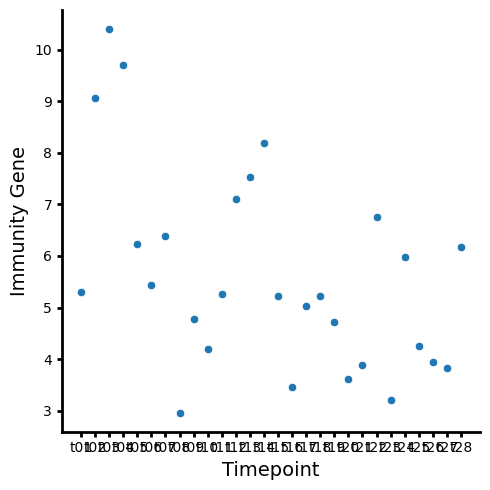

In [60]:
fig, ax = plt.subplots(figsize=(5, 5))
fig.patch.set_facecolor("white")
ax = sns.scatterplot(
    x=diversity_series.index,
    y=groupby_timepoint["AT1G64280"],
)
plt.xlabel("Timepoint", fontsize=14)
plt.ylabel("Immunity Gene", fontsize=14)
sns.despine()
# ax.grid(False)
# plt.axhline(1, color = 'red', linestyle = 'dashed')
ax.spines["bottom"].set_color("black")
ax.spines["bottom"].set_linewidth(2)
ax.spines["left"].set_color("black")
ax.spines["left"].set_linewidth(2)
ax.tick_params(axis="both", width=2)
# plt.xlim((0,3))
# plt.ylim((0, 3))
# handles, labels  =  ax.get_legend_handles_labels()
# ax.legend(loc="upper right")
# plt.title("Current Threshold is 31", fontsize = 20)
plt.xticks(
    fontsize=10,
)  # rotation=90
plt.yticks(fontsize=10)
# plt.ylim(-.02,1)
plt.tight_layout()
# ax.plot([0,1],[0,1], transform=ax.transAxes, linestyle = 'dashed', color = 'k', linewidth = 1.5)
# for line in range(0,full_meta_data.shape[0]):
#      ax.text(pca[:,0][line]+0.01, pca[:,1][line],
#      full_meta_data['plate.pos'][line], horizontalalignment='left',
#      size='medium', color='black', weight='semibold')

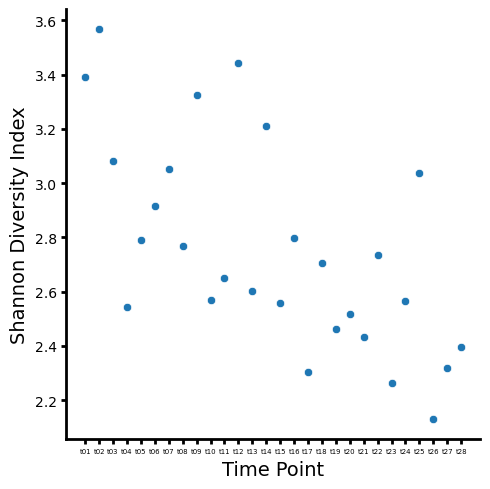

In [61]:
fig, ax = plt.subplots(figsize=(5, 5))
fig.patch.set_facecolor("white")
ax = sns.scatterplot(x=diversity_series.index, y=diversity_series, palette="viridis")
plt.xlabel("Time Point", fontsize=14)
plt.ylabel("Shannon Diversity Index", fontsize=14)
sns.despine()
# ax.grid(False)
# plt.axhline(1, color = 'red', linestyle = 'dashed')
ax.spines["bottom"].set_color("black")
ax.spines["bottom"].set_linewidth(2)
ax.spines["left"].set_color("black")
ax.spines["left"].set_linewidth(2)
ax.tick_params(axis="both", width=2)
# plt.xlim((0,3))
# plt.ylim((0, 3))
# handles, labels  =  ax.get_legend_handles_labels()
# ax.legend(loc="upper right")
# plt.title("Current Threshold is 31", fontsize = 20)
plt.xticks(
    fontsize=5,
)  # rotation=90
plt.yticks(fontsize=10)
# plt.ylim(-.02,1)
plt.tight_layout()
# ax.plot([0,1],[0,1], transform=ax.transAxes, linestyle = 'dashed', color = 'k', linewidth = 1.5)
# for line in range(0,full_meta_data.shape[0]):
#      ax.text(pca[:,0][line]+0.01, pca[:,1][line],
#      full_meta_data['plate.pos'][line], horizontalalignment='left',
#      size='medium', color='black', weight='semibold')

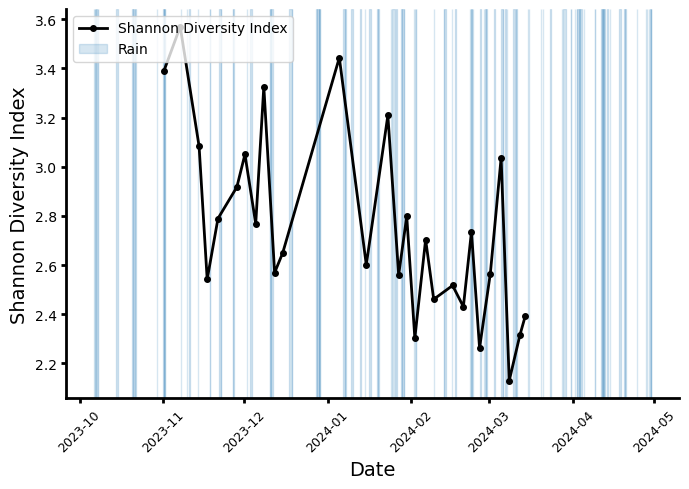

In [62]:
timepoint_datetimes = (
    long_term_metadata[["timepoint", "Date and Time"]]
    .drop_duplicates()
    .sort_values(by="Date and Time")
    .set_index("timepoint")["Date and Time"]
)

shannon_over_time = diversity_series.reindex(timepoint_datetimes.index)
shannon_over_time.index = pd.to_datetime(timepoint_datetimes.values)
shannon_over_time = shannon_over_time.sort_index()

fig, ax = plt.subplots(figsize=(7, 5))
fig.patch.set_facecolor("white")
ax.plot(
    shannon_over_time.index,
    shannon_over_time.values,
    color="black",
    linewidth=2,
    marker="o",
    markersize=4,
    label="Shannon Diversity Index",
)

rain_events = luke_rain_events["prcp"].dropna().sort_index()
if not rain_events.empty:
    rain_block_ids = (
        rain_events.index.to_series().diff() > pd.Timedelta(hours=1)
    ).cumsum()
    for _, block in rain_events.groupby(rain_block_ids):
        ax.axvspan(
            block.index.min(),
            block.index.max() + pd.Timedelta(hours=1),
            color="tab:blue",
            alpha=0.18,
            zorder=0,
        )
    ax.fill_between([], [], color="tab:blue", alpha=0.18, label="Rain")

plt.xlabel("Date", fontsize=14)
plt.ylabel("Shannon Diversity Index", fontsize=14)
sns.despine()
ax.spines["bottom"].set_color("black")
ax.spines["bottom"].set_linewidth(2)
ax.spines["left"].set_color("black")
ax.spines["left"].set_linewidth(2)
ax.tick_params(axis="both", width=2)
ax.tick_params(axis="x", labelsize=9, rotation=45)
ax.tick_params(axis="y", labelsize=10)
ax.legend(loc="upper left")
plt.tight_layout()

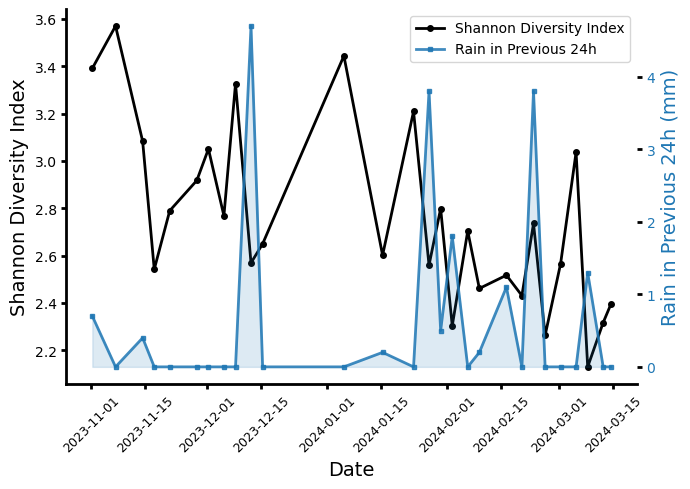

In [63]:
rain_last_24h = luke_hourly_data["prcp"].fillna(0).sort_index().rolling("24h").sum()
rain_last_24h_at_samples = (
    rain_last_24h.reindex(rain_last_24h.index.union(shannon_over_time.index))
    .sort_index()
    .ffill()
    .reindex(shannon_over_time.index)
)

fig, ax = plt.subplots(figsize=(7, 5))
fig.patch.set_facecolor("white")
ax.plot(
    shannon_over_time.index,
    shannon_over_time.values,
    color="black",
    linewidth=2,
    marker="o",
    markersize=4,
    label="Shannon Diversity Index",
)
ax.set_xlabel("Date", fontsize=14)
ax.set_ylabel("Shannon Diversity Index", fontsize=14, color="black")
ax.tick_params(axis="x", width=2, labelsize=9, rotation=45)
ax.tick_params(axis="y", width=2, labelsize=10, labelcolor="black")

ax_rain = ax.twinx()
ax_rain.plot(
    rain_last_24h_at_samples.index,
    rain_last_24h_at_samples.values,
    color="tab:blue",
    linewidth=2,
    marker="s",
    markersize=3.5,
    alpha=0.85,
    label="Rain in Previous 24h",
)
ax_rain.fill_between(
    rain_last_24h_at_samples.index,
    0,
    rain_last_24h_at_samples.values,
    color="tab:blue",
    alpha=0.15,
)
ax_rain.set_ylabel("Rain in Previous 24h (mm)", fontsize=14, color="tab:blue")
ax_rain.tick_params(axis="y", width=2, labelsize=10, labelcolor="tab:blue")

sns.despine(ax=ax)
sns.despine(ax=ax_rain, left=True)
ax.spines["bottom"].set_color("black")
ax.spines["bottom"].set_linewidth(2)
ax.spines["left"].set_color("black")
ax.spines["left"].set_linewidth(2)
ax_rain.spines["right"].set_color("tab:blue")
ax_rain.spines["right"].set_linewidth(2)

lines_left, labels_left = ax.get_legend_handles_labels()
lines_right, labels_right = ax_rain.get_legend_handles_labels()
ax.legend(lines_left + lines_right, labels_left + labels_right, loc="upper right")
plt.tight_layout()

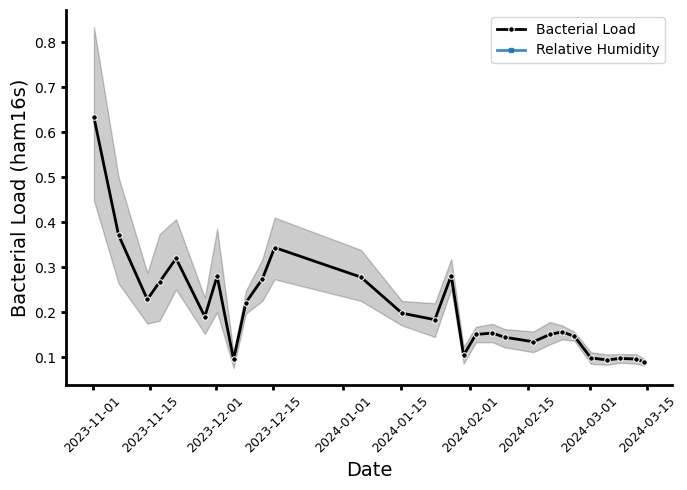

In [ ]:
load_over_time = (
    long_term_metadata_w_load_info.loc[
        long_term_metadata_w_load_info["Experiment Type"] == "Long Term",
        ["Date and Time", "ham16s", "sampID"],
    ]
    .dropna(subset=["Date and Time", "ham16s"])
    .sort_values(by="Date and Time")
)

load_sample_times = pd.to_datetime(load_over_time["Date and Time"])
unique_load_sample_times = pd.DatetimeIndex(load_sample_times.unique()).sort_values()
rain_last_24h_at_unique_load_samples = (
    rain_last_24h.reindex(rain_last_24h.index.union(unique_load_sample_times))
    .sort_index()
    .ffill()
    .reindex(unique_load_sample_times)
)

fig, ax = plt.subplots(figsize=(7, 5))
fig.patch.set_facecolor("white")
sns.lineplot(
    data=load_over_time,
    x=load_sample_times,
    y="ham16s",
    ax=ax,
    color="black",
    linewidth=2,
    marker="o",
    markersize=4,
    label="Bacterial Load",
)
ax.set_xlabel("Date", fontsize=14)
ax.set_ylabel("Bacterial Load (ham16s)", fontsize=14, color="black")
ax.tick_params(axis="x", width=2, labelsize=9, rotation=45)
ax.tick_params(axis="y", width=2, labelsize=10, labelcolor="black")

ax_rain = ax.twinx()
ax_rain.plot(
    unique_load_sample_times,
    rain_last_24h_at_unique_load_samples.values,
    color="tab:blue",
    linewidth=2,
    marker="s",
    markersize=3.5,
    alpha=0.85,
    label="Rain in Previous 24h",
)
ax_rain.fill_between(
    unique_load_sample_times,
    0,
    rain_last_24h_at_unique_load_samples.values,
    color="tab:blue",
    alpha=0.15,
)
ax_rain.set_ylabel("Rain in Previous 24h (mm)", fontsize=14, color="tab:blue")
ax_rain.tick_params(axis="y", width=2, labelsize=10, labelcolor="tab:blue")

sns.despine(ax=ax)
sns.despine(ax=ax_rain, left=True)
ax.spines["bottom"].set_color("black")
ax.spines["bottom"].set_linewidth(2)
ax.spines["left"].set_color("black")
ax.spines["left"].set_linewidth(2)
ax_rain.spines["right"].set_color("tab:blue")
ax_rain.spines["right"].set_linewidth(2)

lines_left, labels_left = ax.get_legend_handles_labels()
lines_right, labels_right = ax_rain.get_legend_handles_labels()
ax.legend(lines_left + lines_right, labels_left + labels_right, loc="upper right")
plt.tight_layout()

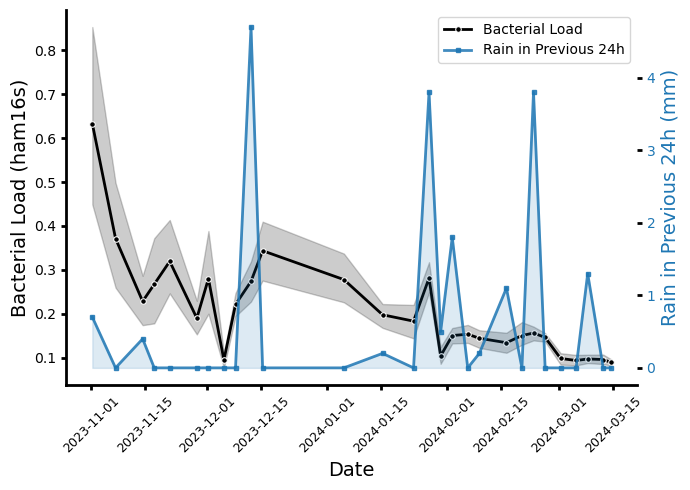

In [99]:
load_over_time = (
    long_term_metadata_w_load_info.loc[
        long_term_metadata_w_load_info["Experiment Type"] == "Long Term",
        ["Date and Time", "ham16s", "sampID"],
    ]
    .dropna(subset=["Date and Time", "ham16s"])
    .sort_values(by="Date and Time")
)

load_sample_times = pd.to_datetime(load_over_time["Date and Time"])
unique_load_sample_times = pd.DatetimeIndex(load_sample_times.unique()).sort_values()
rain_last_24h_at_unique_load_samples = (
    rain_last_24h.reindex(rain_last_24h.index.union(unique_load_sample_times))
    .sort_index()
    .ffill()
    .reindex(unique_load_sample_times)
)

fig, ax = plt.subplots(figsize=(7, 5))
fig.patch.set_facecolor("white")
sns.lineplot(
    data=load_over_time,
    x=load_sample_times,
    y="ham16s",
    ax=ax,
    color="black",
    linewidth=2,
    marker="o",
    markersize=4,
    label="Bacterial Load",
)
ax.set_xlabel("Date", fontsize=14)
ax.set_ylabel("Bacterial Load (ham16s)", fontsize=14, color="black")
ax.tick_params(axis="x", width=2, labelsize=9, rotation=45)
ax.tick_params(axis="y", width=2, labelsize=10, labelcolor="black")

ax_rain = ax.twinx()
ax_rain.plot(
    unique_load_sample_times,
    rain_last_24h_at_unique_load_samples.values,
    color="tab:blue",
    linewidth=2,
    marker="s",
    markersize=3.5,
    alpha=0.85,
    label="Rain in Previous 24h",
)
ax_rain.fill_between(
    unique_load_sample_times,
    0,
    rain_last_24h_at_unique_load_samples.values,
    color="tab:blue",
    alpha=0.15,
)
ax_rain.set_ylabel("Rain in Previous 24h (mm)", fontsize=14, color="tab:blue")
ax_rain.tick_params(axis="y", width=2, labelsize=10, labelcolor="tab:blue")

sns.despine(ax=ax)
sns.despine(ax=ax_rain, left=True)
ax.spines["bottom"].set_color("black")
ax.spines["bottom"].set_linewidth(2)
ax.spines["left"].set_color("black")
ax.spines["left"].set_linewidth(2)
ax_rain.spines["right"].set_color("tab:blue")
ax_rain.spines["right"].set_linewidth(2)

lines_left, labels_left = ax.get_legend_handles_labels()
lines_right, labels_right = ax_rain.get_legend_handles_labels()
ax.legend(lines_left + lines_right, labels_left + labels_right, loc="upper right")
plt.tight_layout()

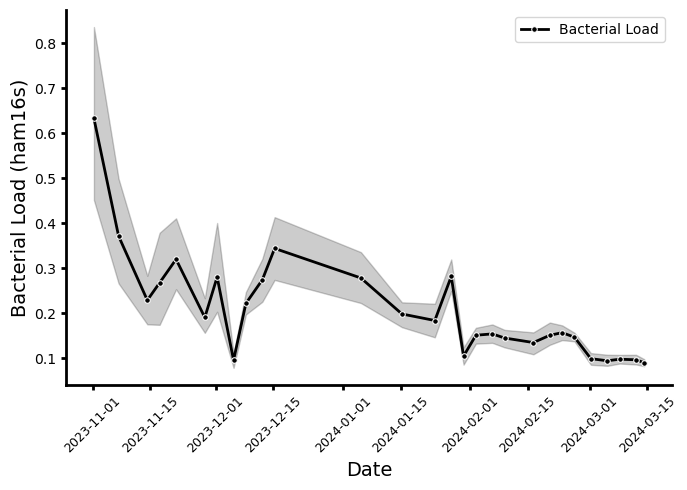

In [101]:
load_over_time = (
    long_term_metadata_w_load_info.loc[
        long_term_metadata_w_load_info["Experiment Type"] == "Long Term",
        ["Date and Time", "ham16s", "sampID"],
    ]
    .dropna(subset=["Date and Time", "ham16s"])
    .sort_values(by="Date and Time")
)

load_sample_times = pd.to_datetime(load_over_time["Date and Time"])
unique_load_sample_times = pd.DatetimeIndex(load_sample_times.unique()).sort_values()
rain_last_24h_at_unique_load_samples = (
    rain_last_24h.reindex(rain_last_24h.index.union(unique_load_sample_times))
    .sort_index()
    .ffill()
    .reindex(unique_load_sample_times)
)

fig, ax = plt.subplots(figsize=(7, 5))
fig.patch.set_facecolor("white")
sns.lineplot(
    data=load_over_time,
    x=load_sample_times,
    y="ham16s",
    ax=ax,
    color="black",
    linewidth=2,
    marker="o",
    markersize=4,
    label="Bacterial Load",
)
ax.set_xlabel("Date", fontsize=14)
ax.set_ylabel("Bacterial Load (ham16s)", fontsize=14, color="black")
ax.tick_params(axis="x", width=2, labelsize=9, rotation=45)
ax.tick_params(axis="y", width=2, labelsize=10, labelcolor="black")


sns.despine(ax=ax)

ax.spines["bottom"].set_color("black")
ax.spines["bottom"].set_linewidth(2)
ax.spines["left"].set_color("black")
ax.spines["left"].set_linewidth(2)
ax_rain.spines["right"].set_color("tab:blue")
ax_rain.spines["right"].set_linewidth(2)

lines_left, labels_left = ax.get_legend_handles_labels()
plt.tight_layout()

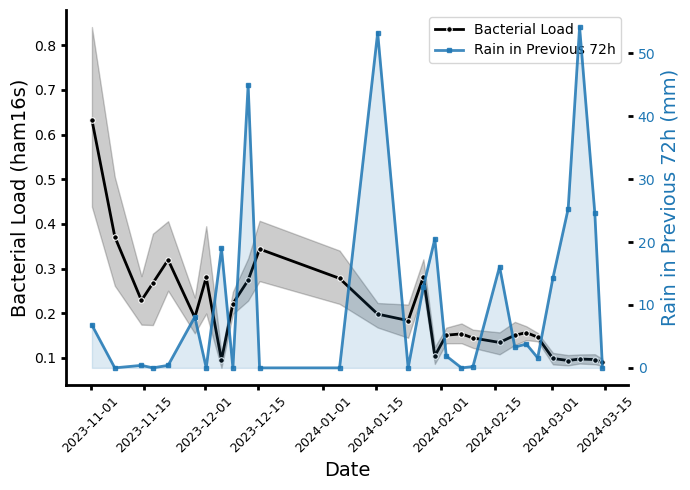

In [94]:
rain_last_72h = luke_hourly_data["prcp"].fillna(0).sort_index().rolling("72h").sum()

rain_last_72h_at_unique_load_samples = (
    rain_last_72h.reindex(rain_last_72h.index.union(unique_load_sample_times))
    .sort_index()
    .ffill()
    .reindex(unique_load_sample_times)
)

fig, ax = plt.subplots(figsize=(7, 5))
fig.patch.set_facecolor("white")
sns.lineplot(
    data=load_over_time,
    x=load_sample_times,
    y="ham16s",
    ax=ax,
    color="black",
    linewidth=2,
    marker="o",
    markersize=4,
    label="Bacterial Load",
)
ax.set_xlabel("Date", fontsize=14)
ax.set_ylabel("Bacterial Load (ham16s)", fontsize=14, color="black")
ax.tick_params(axis="x", width=2, labelsize=9, rotation=45)
ax.tick_params(axis="y", width=2, labelsize=10, labelcolor="black")

ax_rain = ax.twinx()
ax_rain.plot(
    unique_load_sample_times,
    rain_last_72h_at_unique_load_samples.values,
    color="tab:blue",
    linewidth=2,
    marker="s",
    markersize=3.5,
    alpha=0.85,
    label="Rain in Previous 72h",
)
ax_rain.fill_between(
    unique_load_sample_times,
    0,
    rain_last_72h_at_unique_load_samples.values,
    color="tab:blue",
    alpha=0.15,
)
ax_rain.set_ylabel("Rain in Previous 72h (mm)", fontsize=14, color="tab:blue")
ax_rain.tick_params(axis="y", width=2, labelsize=10, labelcolor="tab:blue")

sns.despine(ax=ax)
sns.despine(ax=ax_rain, left=True)
ax.spines["bottom"].set_color("black")
ax.spines["bottom"].set_linewidth(2)
ax.spines["left"].set_color("black")
ax.spines["left"].set_linewidth(2)
ax_rain.spines["right"].set_color("tab:blue")
ax_rain.spines["right"].set_linewidth(2)

lines_left, labels_left = ax.get_legend_handles_labels()
lines_right, labels_right = ax_rain.get_legend_handles_labels()
ax.legend(lines_left + lines_right, labels_left + labels_right, loc="upper right")
plt.tight_layout()

In [87]:
load_vs_rain_df = load_over_time.copy()
load_vs_rain_df['Date and Time'] = pd.to_datetime(load_vs_rain_df['Date and Time'])
load_vs_rain_df['Rain in Previous 24h'] = load_vs_rain_df['Date and Time'].map(rain_last_24h_at_unique_load_samples)

load_vs_rain_df = load_vs_rain_df.merge(
    long_term_metadata[['sampID', 'Time Since Rain']], 
    on='sampID', 
    how='left'
)
load_vs_rain_df['Hours Since Rain'] = load_vs_rain_df['Time Since Rain'].dt.total_seconds() / 3600

load_vs_rain_clean = load_vs_rain_df.dropna(subset=['ham16s', 'Rain in Previous 24h', 'Hours Since Rain']).copy()

# Correct for general time trends
load_vs_rain_clean['Time_Numeric'] = (load_vs_rain_clean['Date and Time'] - load_vs_rain_clean['Date and Time'].min()).dt.total_seconds()

# Linear Detrending
slope, intercept, _, _, _ = scipy.stats.linregress(load_vs_rain_clean['Time_Numeric'], load_vs_rain_clean['ham16s'])
load_vs_rain_clean['ham16s_detrended_linear'] = load_vs_rain_clean['ham16s'] - (slope * load_vs_rain_clean['Time_Numeric'] + intercept)

# Polynomial Detrending (degree 2 for potential seasonal curve)
coeffs = np.polyfit(load_vs_rain_clean['Time_Numeric'], load_vs_rain_clean['ham16s'], 2)
load_vs_rain_clean['ham16s_detrended_poly'] = load_vs_rain_clean['ham16s'] - np.polyval(coeffs, load_vs_rain_clean['Time_Numeric'])

def print_corrs(label, y_col):
    pr, pp = scipy.stats.pearsonr(load_vs_rain_clean['Rain in Previous 24h'], load_vs_rain_clean[y_col])
    sr, sp = scipy.stats.spearmanr(load_vs_rain_clean['Rain in Previous 24h'], load_vs_rain_clean[y_col])
    pr2, pp2 = scipy.stats.pearsonr(load_vs_rain_clean['Hours Since Rain'], load_vs_rain_clean[y_col])
    sr2, sp2 = scipy.stats.spearmanr(load_vs_rain_clean['Hours Since Rain'], load_vs_rain_clean[y_col])
    print(f"--- {label} ---")
    print(f"Vs. Rain in Previous 24h | Pearson r: {pr:5.3f} (p={pp:.3e}) | Spearman r: {sr:5.3f} (p={sp:.3e})")
    print(f"Vs. Hours Since Rain     | Pearson r: {pr2:5.3f} (p={pp2:.3e}) | Spearman r: {sr2:5.3f} (p={sp2:.3e})\n")

print_corrs("Original Bacterial Load", "ham16s")
print_corrs("Detrended Bacterial Load (Linear)", "ham16s_detrended_linear")
print_corrs("Detrended Bacterial Load (Quadratic)", "ham16s_detrended_poly")

--- Original Bacterial Load ---
Vs. Rain in Previous 24h | Pearson r: 0.063 (p=3.492e-01) | Spearman r: 0.070 (p=3.024e-01)
Vs. Hours Since Rain     | Pearson r: 0.142 (p=3.505e-02) | Spearman r: 0.156 (p=2.015e-02)

--- Detrended Bacterial Load (Linear) ---
Vs. Rain in Previous 24h | Pearson r: 0.145 (p=3.120e-02) | Spearman r: 0.172 (p=1.027e-02)
Vs. Hours Since Rain     | Pearson r: 0.012 (p=8.635e-01) | Spearman r: -0.070 (p=2.992e-01)

--- Detrended Bacterial Load (Quadratic) ---
Vs. Rain in Previous 24h | Pearson r: 0.179 (p=7.572e-03) | Spearman r: 0.225 (p=7.223e-04)
Vs. Hours Since Rain     | Pearson r: 0.024 (p=7.233e-01) | Spearman r: -0.088 (p=1.916e-01)



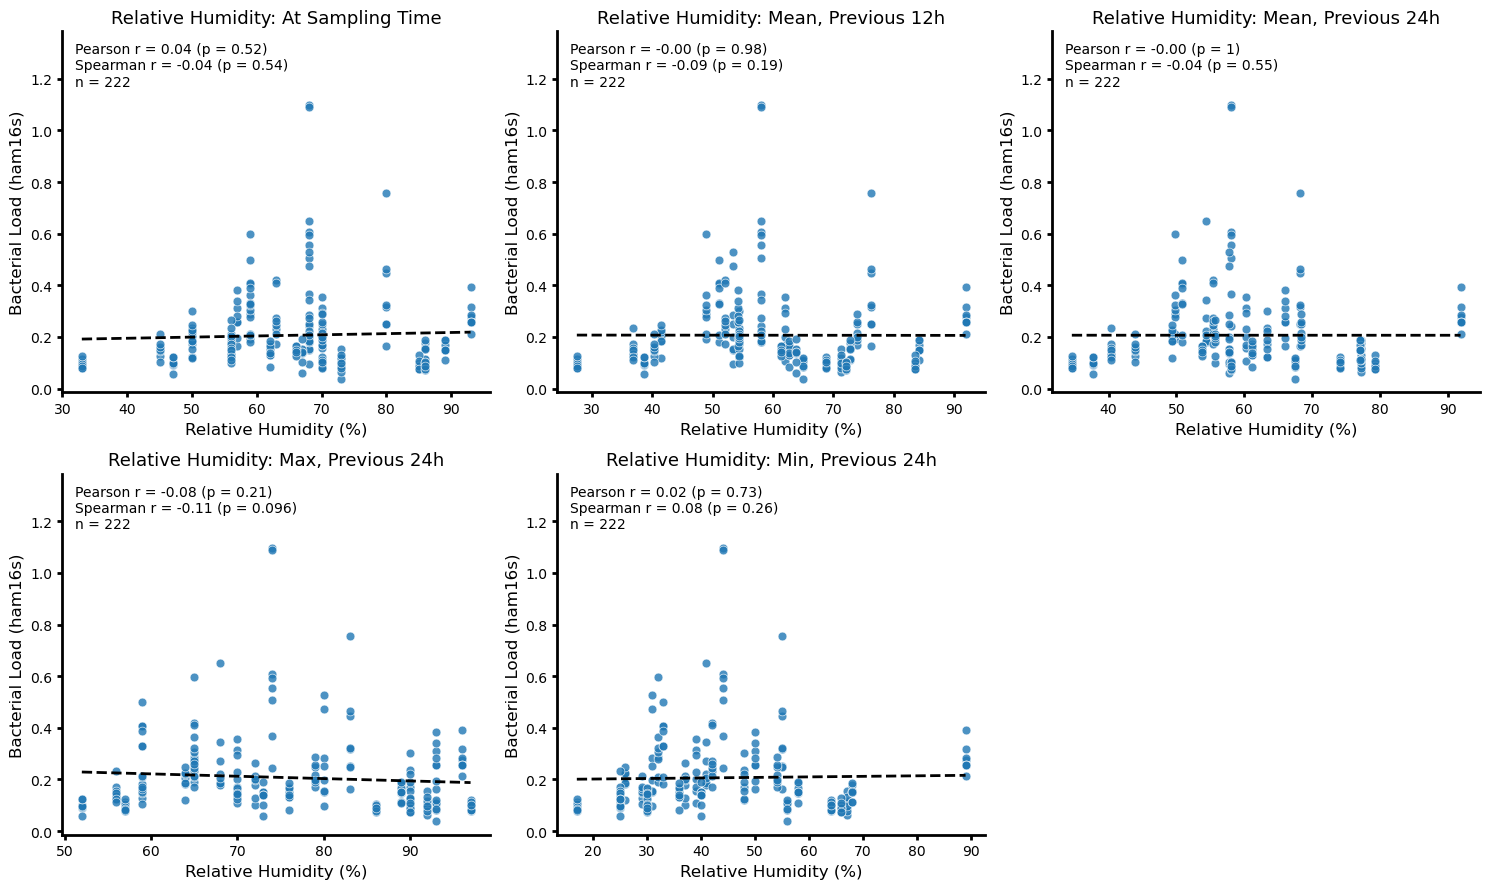

In [96]:
# Bacterial load vs. relative humidity (rhum, %).
# Max/min are taken over the 24h window preceding each sample.
rhum_hourly = (
    luke_hourly_data["rhum"].sort_index().interpolate(method="time", limit_direction="both")
)

rhum_metrics = {
    "At Sampling Time": rhum_hourly,
    "Mean, Previous 12h": rhum_hourly.rolling("12h").mean(),
    "Mean, Previous 24h": rhum_hourly.rolling("24h").mean(),
    "Max, Previous 24h": rhum_hourly.rolling("24h").max(),
    "Min, Previous 24h": rhum_hourly.rolling("24h").min(),
}


def at_load_sample_times(series):
    """Value of an hourly weather series carried forward to each sampling time."""
    return (
        series.reindex(series.index.union(unique_load_sample_times))
        .sort_index()
        .ffill()
        .reindex(unique_load_sample_times)
    )


load_vs_rhum_df = load_over_time.copy()
load_vs_rhum_df["Date and Time"] = pd.to_datetime(load_vs_rhum_df["Date and Time"])
for rhum_label, rhum_series in rhum_metrics.items():
    load_vs_rhum_df[rhum_label] = load_vs_rhum_df["Date and Time"].map(
        at_load_sample_times(rhum_series)
    )

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.patch.set_facecolor("white")
axes = axes.ravel()

for ax, rhum_label in zip(axes, rhum_metrics):
    panel = load_vs_rhum_df.dropna(subset=["ham16s", rhum_label])
    ax.scatter(
        panel[rhum_label],
        panel["ham16s"],
        s=40,
        color="tab:blue",
        alpha=0.8,
        edgecolor="white",
        linewidth=0.5,
    )
    if len(panel) > 2 and panel[rhum_label].nunique() > 1:
        slope, intercept, _, _, _ = scipy.stats.linregress(
            panel[rhum_label], panel["ham16s"]
        )
        x_fit = np.linspace(panel[rhum_label].min(), panel[rhum_label].max(), 100)
        ax.plot(x_fit, slope * x_fit + intercept, color="black", linewidth=2, linestyle="dashed")
        pr, pp = scipy.stats.pearsonr(panel[rhum_label], panel["ham16s"])
        sr, sp = scipy.stats.spearmanr(panel[rhum_label], panel["ham16s"])
        annotation = (
            f"Pearson r = {pr:.2f} (p = {pp:.2g})\n"
            f"Spearman r = {sr:.2f} (p = {sp:.2g})\n"
            f"n = {len(panel)}"
        )
    else:
        annotation = f"n = {len(panel)} (too few points)"
    y_low, y_high = ax.get_ylim()  # headroom so the stats text clears the points
    ax.set_ylim(y_low, y_high + 0.2 * (y_high - y_low))
    ax.text(
        0.03,
        0.97,
        annotation,
        transform=ax.transAxes,
        va="top",
        ha="left",
        fontsize=10,
    )
    ax.set_title(f"Relative Humidity: {rhum_label}", fontsize=13)
    ax.set_xlabel("Relative Humidity (%)", fontsize=12)
    ax.set_ylabel("Bacterial Load (ham16s)", fontsize=12)
    sns.despine(ax=ax)
    ax.spines["bottom"].set_color("black")
    ax.spines["bottom"].set_linewidth(2)
    ax.spines["left"].set_color("black")
    ax.spines["left"].set_linewidth(2)
    ax.tick_params(axis="both", width=2, labelsize=10)

axes[-1].axis("off")
plt.tight_layout()


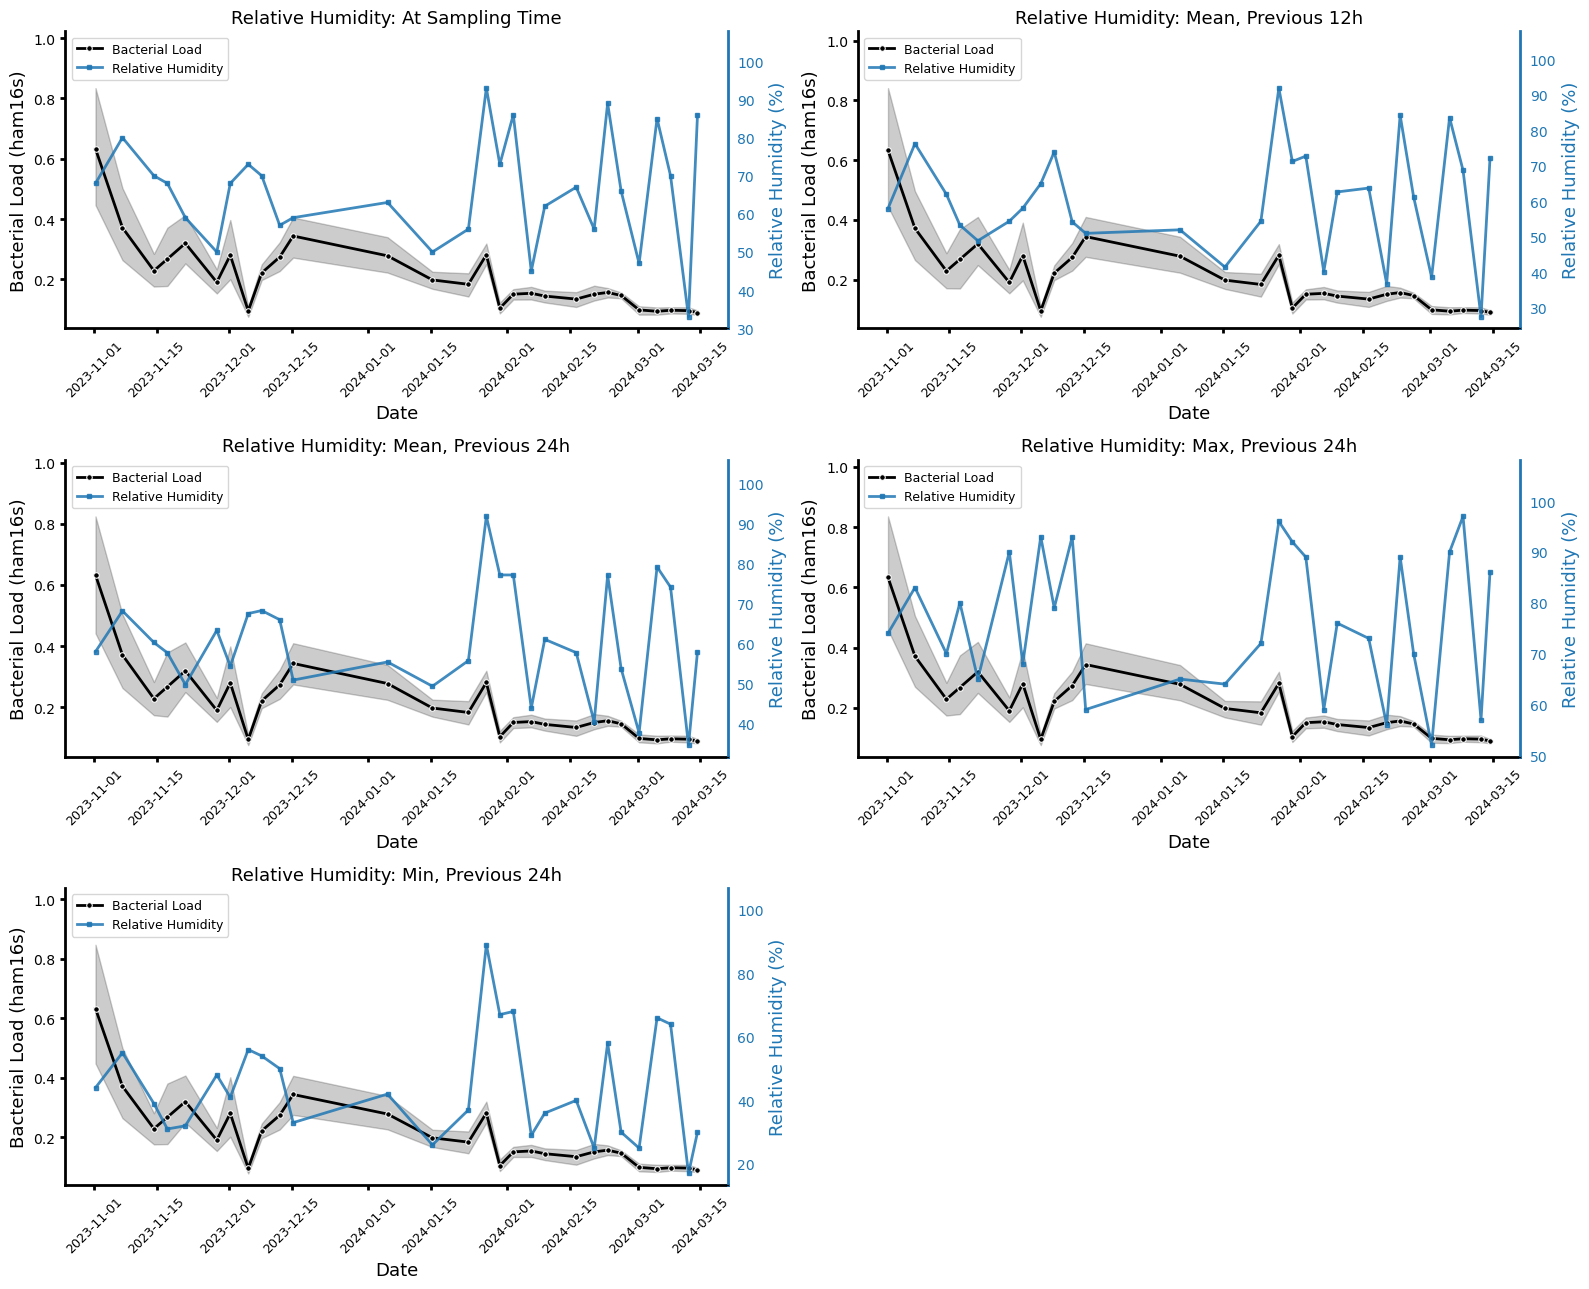

In [97]:
# Same five humidity metrics over time, against bacterial load, so the shared
# seasonal trend is visible. Reuses rhum_metrics / at_load_sample_times from above.
fig, axes = plt.subplots(3, 2, figsize=(16, 13))
fig.patch.set_facecolor("white")
axes = axes.ravel()

for ax, (rhum_label, rhum_series) in zip(axes, rhum_metrics.items()):
    rhum_at_samples = at_load_sample_times(rhum_series)

    sns.lineplot(
        data=load_over_time,
        x=load_sample_times,
        y="ham16s",
        ax=ax,
        color="black",
        linewidth=2,
        marker="o",
        markersize=4,
        label="Bacterial Load",
    )
    ax.set_xlabel("Date", fontsize=13)
    ax.set_ylabel("Bacterial Load (ham16s)", fontsize=13, color="black")
    ax.tick_params(axis="x", width=2, labelsize=9, rotation=45)
    ax.tick_params(axis="y", width=2, labelsize=10, labelcolor="black")

    ax_rhum = ax.twinx()
    ax_rhum.plot(
        unique_load_sample_times,
        rhum_at_samples.values,
        color="tab:blue",
        linewidth=2,
        marker="s",
        markersize=3.5,
        alpha=0.85,
        label="Relative Humidity",
    )
    ax_rhum.set_ylabel("Relative Humidity (%)", fontsize=13, color="tab:blue")
    ax_rhum.tick_params(axis="y", width=2, labelsize=10, labelcolor="tab:blue")

    ax.set_title(f"Relative Humidity: {rhum_label}", fontsize=13)
    sns.despine(ax=ax)
    sns.despine(ax=ax_rhum, left=True, right=False)
    ax.spines["bottom"].set_color("black")
    ax.spines["bottom"].set_linewidth(2)
    ax.spines["left"].set_color("black")
    ax.spines["left"].set_linewidth(2)
    ax_rhum.spines["right"].set_color("tab:blue")
    ax_rhum.spines["right"].set_linewidth(2)

    for panel_ax in (ax, ax_rhum):  # headroom so the legend clears the lines
        y_low, y_high = panel_ax.get_ylim()
        panel_ax.set_ylim(y_low, y_high + 0.18 * (y_high - y_low))

    lines_left, labels_left = ax.get_legend_handles_labels()
    lines_right, labels_right = ax_rhum.get_legend_handles_labels()
    ax.legend(
        lines_left + lines_right,
        labels_left + labels_right,
        loc="upper left",
        fontsize=9,
    )

axes[-1].axis("off")
plt.tight_layout()


In [65]:
rain_last_24h

time
2023-10-01 00:00:00    0.0
2023-10-01 01:00:00    0.0
2023-10-01 02:00:00    0.0
2023-10-01 03:00:00    0.0
2023-10-01 04:00:00    0.0
                      ... 
2024-04-29 20:00:00    2.0
2024-04-29 21:00:00    2.1
2024-04-29 22:00:00    2.1
2024-04-29 23:00:00    2.1
2024-04-30 00:00:00    9.5
Freq: h, Name: prcp, Length: 5089, dtype: float64

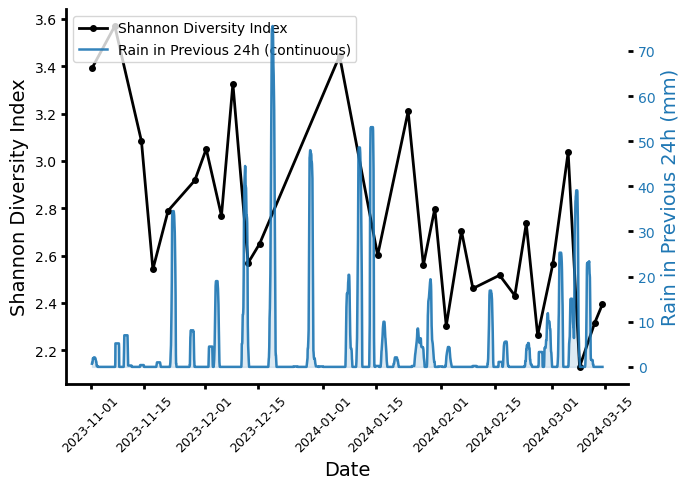

In [66]:
rain_last_24h_continuous = rain_last_24h.loc[
    shannon_over_time.index.min() : shannon_over_time.index.max()
]

fig, ax = plt.subplots(figsize=(7, 5))
fig.patch.set_facecolor("white")
ax.plot(
    shannon_over_time.index,
    shannon_over_time.values,
    color="black",
    linewidth=2,
    marker="o",
    markersize=4,
    label="Shannon Diversity Index",
)
ax.set_xlabel("Date", fontsize=14)
ax.set_ylabel("Shannon Diversity Index", fontsize=14, color="black")
ax.tick_params(axis="x", width=2, labelsize=9, rotation=45)
ax.tick_params(axis="y", width=2, labelsize=10, labelcolor="black")

ax_rain = ax.twinx()
ax_rain.plot(
    rain_last_24h_continuous.index,
    rain_last_24h_continuous.values,
    color="tab:blue",
    linewidth=1.8,
    alpha=0.9,
    label="Rain in Previous 24h (continuous)",
)
ax_rain.fill_between(
    rain_last_24h_continuous.index,
    0,
    rain_last_24h_continuous.values,
    color="tab:blue",
    alpha=0.15,
)
ax_rain.set_ylabel("Rain in Previous 24h (mm)", fontsize=14, color="tab:blue")
ax_rain.tick_params(axis="y", width=2, labelsize=10, labelcolor="tab:blue")

sns.despine(ax=ax)
sns.despine(ax=ax_rain, left=True)
ax.spines["bottom"].set_color("black")
ax.spines["bottom"].set_linewidth(2)
ax.spines["left"].set_color("black")
ax.spines["left"].set_linewidth(2)
ax_rain.spines["right"].set_color("tab:blue")
ax_rain.spines["right"].set_linewidth(2)

lines_left, labels_left = ax.get_legend_handles_labels()
lines_right, labels_right = ax_rain.get_legend_handles_labels()
ax.legend(lines_left + lines_right, labels_left + labels_right, loc="upper left")
plt.tight_layout()

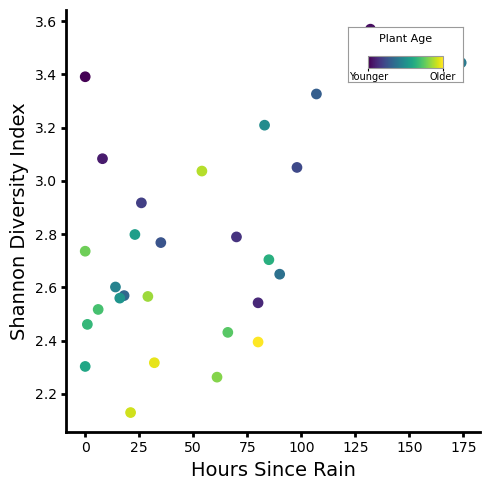

In [67]:
sample_age = (
    pd.Index(diversity_series.index)
    .str.extract(r"(\d+)", expand=False)
    .astype(int)
    .to_numpy()
)

fig, ax = plt.subplots(figsize=(5, 5))
fig.patch.set_facecolor("white")
scatter = ax.scatter(
    timepoint_time_since_rain["Hours Since Rain"],
    diversity_series,
    c=sample_age,
    cmap="viridis",
    vmin=sample_age.min(),
    vmax=sample_age.max(),
    s=45,
)
legend_box = ax.inset_axes([0.68, 0.83, 0.28, 0.13])
legend_box.set_facecolor("white")
legend_box.set_xticks([])
legend_box.set_yticks([])
legend_box.set_zorder(5)
for spine in legend_box.spines.values():
    spine.set_color("#9a9a9a")
    spine.set_linewidth(0.8)
legend_box.text(0.5, 0.78, "Plant Age", ha="center", va="center", fontsize=8)
cax = legend_box.inset_axes([0.18, 0.25, 0.64, 0.22])
cax.set_facecolor("white")
colorbar = fig.colorbar(scatter, cax=cax, orientation="horizontal")
colorbar.set_ticks([sample_age.min(), sample_age.max()])
colorbar.set_ticklabels(["Younger", "Older"])
colorbar.ax.tick_params(labelsize=7, length=2, pad=1)
for spine in colorbar.ax.spines.values():
    spine.set_color("#9a9a9a")
    spine.set_linewidth(0.8)

plt.xlabel("Hours Since Rain", fontsize=14)
plt.ylabel("Shannon Diversity Index", fontsize=14)
sns.despine()
# ax.grid(False)
# plt.axhline(1, color = 'red', linestyle = 'dashed')
ax.spines["bottom"].set_color("black")
ax.spines["bottom"].set_linewidth(2)
ax.spines["left"].set_color("black")
ax.spines["left"].set_linewidth(2)
ax.tick_params(axis="both", width=2)
# plt.xlim((0,3))
# plt.ylim((0, 3))
# handles, labels  =  ax.get_legend_handles_labels()
# plt.title("Current Threshold is 31", fontsize = 20)
plt.xticks(
    fontsize=10,
)  # rotation=90
plt.yticks(fontsize=10)
# plt.ylim(-.02,1)
plt.tight_layout()
# ax.plot([0,1],[0,1], transform=ax.transAxes, linestyle = 'dashed', color = 'k', linewidth = 1.5)
# for line in range(0,full_meta_data.shape[0]):
#      ax.text(pca[:,0][line]+0.01, pca[:,1][line],
#      full_meta_data['plate.pos'][line], horizontalalignment='left',
#      size='medium', color='black', weight='semibold')

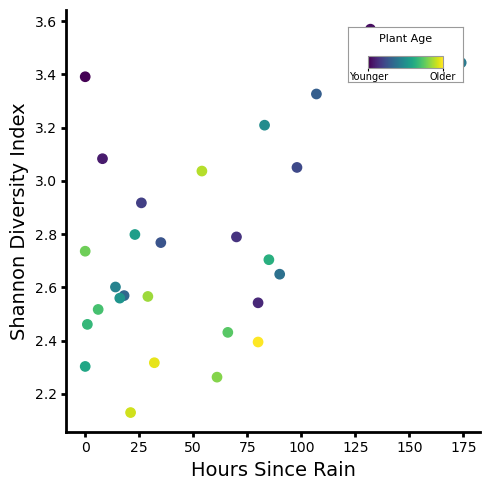

In [68]:
sample_age = (
    pd.Index(diversity_series.index)
    .str.extract(r"(\d+)", expand=False)
    .astype(int)
    .to_numpy()
)

fig, ax = plt.subplots(figsize=(5, 5))
fig.patch.set_facecolor("white")
scatter = ax.scatter(
    timepoint_time_since_rain["Hours Since Rain"],
    diversity_series,
    c=sample_age,
    cmap="viridis",
    vmin=sample_age.min(),
    vmax=sample_age.max(),
    s=45,
)
legend_box = ax.inset_axes([0.68, 0.83, 0.28, 0.13])
legend_box.set_facecolor("white")
legend_box.set_xticks([])
legend_box.set_yticks([])
legend_box.set_zorder(5)
for spine in legend_box.spines.values():
    spine.set_color("#9a9a9a")
    spine.set_linewidth(0.8)
legend_box.text(0.5, 0.78, "Plant Age", ha="center", va="center", fontsize=8)
cax = legend_box.inset_axes([0.18, 0.25, 0.64, 0.22])
cax.set_facecolor("white")
colorbar = fig.colorbar(scatter, cax=cax, orientation="horizontal")
colorbar.set_ticks([sample_age.min(), sample_age.max()])
colorbar.set_ticklabels(["Younger", "Older"])
colorbar.ax.tick_params(labelsize=7, length=2, pad=1)
for spine in colorbar.ax.spines.values():
    spine.set_color("#9a9a9a")
    spine.set_linewidth(0.8)

plt.xlabel("Hours Since Rain", fontsize=14)
plt.ylabel("Shannon Diversity Index", fontsize=14)
sns.despine()
# ax.grid(False)
# plt.axhline(1, color = 'red', linestyle = 'dashed')
ax.spines["bottom"].set_color("black")
ax.spines["bottom"].set_linewidth(2)
ax.spines["left"].set_color("black")
ax.spines["left"].set_linewidth(2)
ax.tick_params(axis="both", width=2)
# plt.xlim((0,3))
# plt.ylim((0, 3))
# handles, labels  =  ax.get_legend_handles_labels()
# plt.title("Current Threshold is 31", fontsize = 20)
plt.xticks(
    fontsize=10,
)  # rotation=90
plt.yticks(fontsize=10)
# plt.ylim(-.02,1)
plt.tight_layout()
# ax.plot([0,1],[0,1], transform=ax.transAxes, linestyle = 'dashed', color = 'k', linewidth = 1.5)
# for line in range(0,full_meta_data.shape[0]):
#      ax.text(pca[:,0][line]+0.01, pca[:,1][line],
#      full_meta_data['plate.pos'][line], horizontalalignment='left',
#      size='medium', color='black', weight='semibold')

In [69]:
scipy.stats.pearsonr(
    timepoint_time_since_rain["Hours Since Rain"],
    diversity_series,
)
##light rain .35 pearson
## moderate rain .31 pearson
## heavy rain .188

PearsonRResult(statistic=np.float64(0.4894878235185018), pvalue=np.float64(0.008200631292174165))

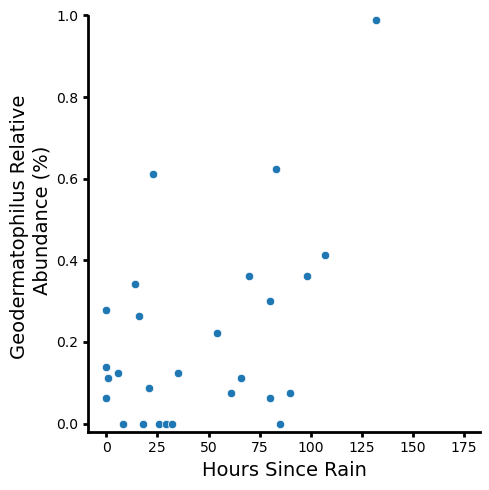

In [70]:
fig, ax = plt.subplots(figsize=(5, 5))
fig.patch.set_facecolor("white")
ax = sns.scatterplot(
    x=timepoint_time_since_rain["Hours Since Rain"],
    y=timepoint_abundance_matrix["Geodermatophilus"],
)
plt.xlabel("Hours Since Rain", fontsize=14)
plt.ylabel("Geodermatophilus Relative \n Abundance (%)", fontsize=14)
sns.despine()
# ax.grid(False)
# plt.axhline(1, color = 'red', linestyle = 'dashed')
ax.spines["bottom"].set_color("black")
ax.spines["bottom"].set_linewidth(2)
ax.spines["left"].set_color("black")
ax.spines["left"].set_linewidth(2)
ax.tick_params(axis="both", width=2)
# plt.xlim((0,3))
# plt.ylim((0, 3))
# handles, labels  =  ax.get_legend_handles_labels()
# ax.legend(loc="upper right")
# plt.title("Current Threshold is 31", fontsize = 20)
plt.xticks(
    fontsize=10,
)  # rotation=90
plt.yticks(fontsize=10)
plt.ylim(-0.02, 1)
plt.tight_layout()
# ax.plot([0,1],[0,1], transform=ax.transAxes, linestyle = 'dashed', color = 'k', linewidth = 1.5)
# for line in range(0,full_meta_data.shape[0]):
#      ax.text(pca[:,0][line]+0.01, pca[:,1][line],
#      full_meta_data['plate.pos'][line], horizontalalignment='left',
#      size='medium', color='black', weight='semibold')

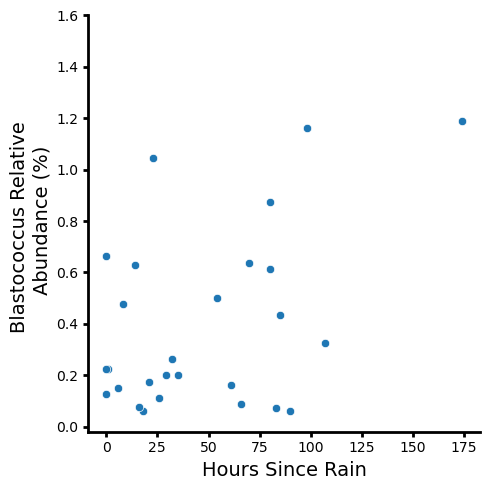

In [71]:
fig, ax = plt.subplots(figsize=(5, 5))
fig.patch.set_facecolor("white")
ax = sns.scatterplot(
    x=timepoint_time_since_rain["Hours Since Rain"],
    y=timepoint_abundance_matrix["Blastococcus"],
)
plt.xlabel("Hours Since Rain", fontsize=14)
plt.ylabel("Blastococcus Relative \n Abundance (%)", fontsize=14)
sns.despine()
# ax.grid(False)
# plt.axhline(1, color = 'red', linestyle = 'dashed')
ax.spines["bottom"].set_color("black")
ax.spines["bottom"].set_linewidth(2)
ax.spines["left"].set_color("black")
ax.spines["left"].set_linewidth(2)
ax.tick_params(axis="both", width=2)
# plt.xlim((0,3))
# plt.ylim((0, 3))
# handles, labels  =  ax.get_legend_handles_labels()
# ax.legend(loc="upper right")
# plt.title("Current Threshold is 31", fontsize = 20)
plt.xticks(
    fontsize=10,
)  # rotation=90
plt.yticks(fontsize=10)
plt.ylim(-0.02, 1.6)
plt.tight_layout()
# ax.plot([0,1],[0,1], transform=ax.transAxes, linestyle = 'dashed', color = 'k', linewidth = 1.5)
# for line in range(0,full_meta_data.shape[0]):
#      ax.text(pca[:,0][line]+0.01, pca[:,1][line],
#      full_meta_data['plate.pos'][line], horizontalalignment='left',
#      size='medium', color='black', weight='semibold')

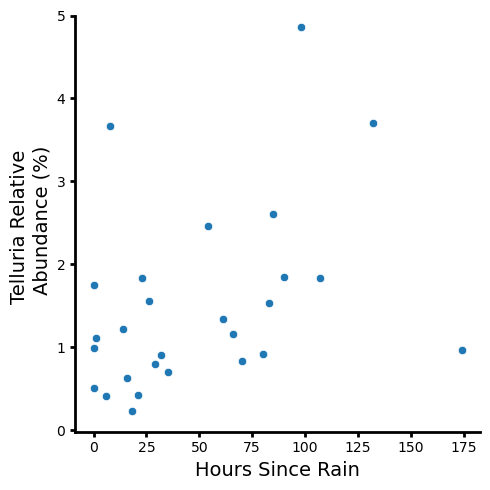

In [72]:
fig, ax = plt.subplots(figsize=(5, 5))
fig.patch.set_facecolor("white")
ax = sns.scatterplot(
    x=timepoint_time_since_rain["Hours Since Rain"],
    y=timepoint_abundance_matrix["Telluria_573210"],
)
plt.xlabel("Hours Since Rain", fontsize=14)
plt.ylabel("Telluria Relative \n Abundance (%)", fontsize=14)
sns.despine()
# ax.grid(False)
# plt.axhline(1, color = 'red', linestyle = 'dashed')
ax.spines["bottom"].set_color("black")
ax.spines["bottom"].set_linewidth(2)
ax.spines["left"].set_color("black")
ax.spines["left"].set_linewidth(2)
ax.tick_params(axis="both", width=2)
# plt.xlim((0,3))
# plt.ylim((0, 3))
# handles, labels  =  ax.get_legend_handles_labels()
# ax.legend(loc="upper right")
# plt.title("Current Threshold is 31", fontsize = 20)
plt.xticks(
    fontsize=10,
)  # rotation=90
plt.yticks(fontsize=10)
plt.ylim(-0.02, 5)
plt.tight_layout()
# ax.plot([0,1],[0,1], transform=ax.transAxes, linestyle = 'dashed', color = 'k', linewidth = 1.5)
# for line in range(0,full_meta_data.shape[0]):
#      ax.text(pca[:,0][line]+0.01, pca[:,1][line],
#      full_meta_data['plate.pos'][line], horizontalalignment='left',
#      size='medium', color='black', weight='semibold')

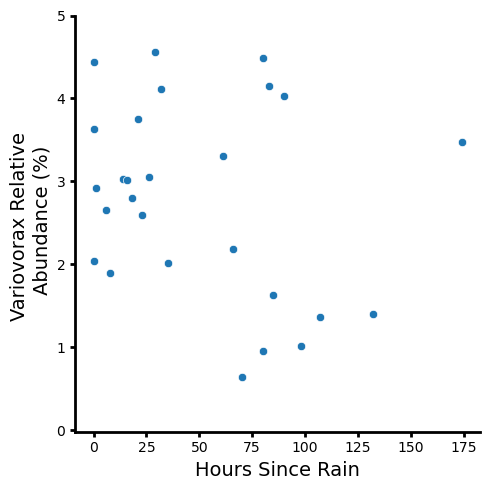

In [73]:
fig, ax = plt.subplots(figsize=(5, 5))
fig.patch.set_facecolor("white")
ax = sns.scatterplot(
    x=timepoint_time_since_rain["Hours Since Rain"],
    y=timepoint_abundance_matrix["Variovorax"],
)
plt.xlabel("Hours Since Rain", fontsize=14)
plt.ylabel("Variovorax Relative \n Abundance (%)", fontsize=14)
sns.despine()
# ax.grid(False)
# plt.axhline(1, color = 'red', linestyle = 'dashed')
ax.spines["bottom"].set_color("black")
ax.spines["bottom"].set_linewidth(2)
ax.spines["left"].set_color("black")
ax.spines["left"].set_linewidth(2)
ax.tick_params(axis="both", width=2)
# plt.xlim((0,3))
# plt.ylim((0, 3))
# handles, labels  =  ax.get_legend_handles_labels()
# ax.legend(loc="upper right")
# plt.title("Current Threshold is 31", fontsize = 20)
plt.xticks(
    fontsize=10,
)  # rotation=90
plt.yticks(fontsize=10)
plt.ylim(-0.02, 5)
plt.tight_layout()
# ax.plot([0,1],[0,1], transform=ax.transAxes, linestyle = 'dashed', color = 'k', linewidth = 1.5)
# for line in range(0,full_meta_data.shape[0]):
#      ax.text(pca[:,0][line]+0.01, pca[:,1][line],
#      full_meta_data['plate.pos'][line], horizontalalignment='left',
#      size='medium', color='black', weight='semibold')

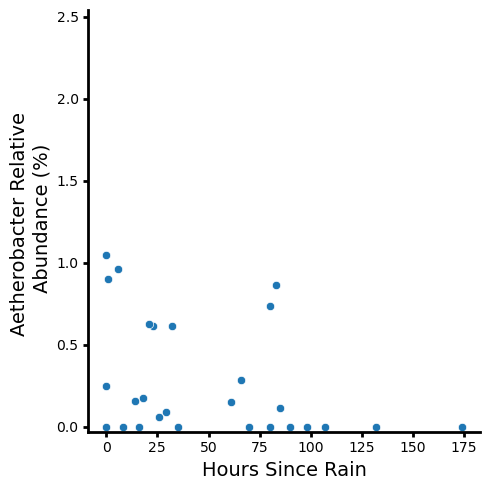

In [74]:
fig, ax = plt.subplots(figsize=(5, 5))
fig.patch.set_facecolor("white")
ax = sns.scatterplot(
    x=timepoint_time_since_rain["Hours Since Rain"],
    y=timepoint_abundance_matrix["Aetherobacter"],
)
plt.xlabel("Hours Since Rain", fontsize=14)
plt.ylabel("Aetherobacter Relative \n Abundance (%)", fontsize=14)
sns.despine()
# ax.grid(False)
# plt.axhline(1, color = 'red', linestyle = 'dashed')
ax.spines["bottom"].set_color("black")
ax.spines["bottom"].set_linewidth(2)
ax.spines["left"].set_color("black")
ax.spines["left"].set_linewidth(2)
ax.tick_params(axis="both", width=2)
# plt.xlim((0,3))
# plt.ylim((0, 3))
# handles, labels  =  ax.get_legend_handles_labels()
# ax.legend(loc="upper right")
# plt.title("Current Threshold is 31", fontsize = 20)
plt.xticks(
    fontsize=10,
)  # rotation=90
plt.yticks(fontsize=10)
plt.ylim(-0.03, 2.54)
plt.tight_layout()
# ax.plot([0,1],[0,1], transform=ax.transAxes, linestyle = 'dashed', color = 'k', linewidth = 1.5)
# for line in range(0,full_meta_data.shape[0]):
#      ax.text(pca[:,0][line]+0.01, pca[:,1][line],
#      full_meta_data['plate.pos'][line], horizontalalignment='left',
#      size='medium', color='black', weight='semibold')

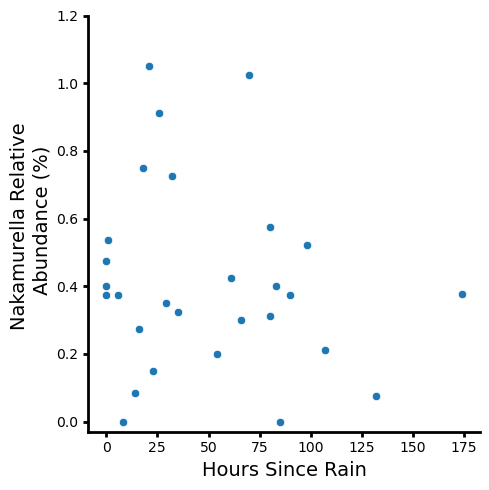

In [75]:
fig, ax = plt.subplots(figsize=(5, 5))
fig.patch.set_facecolor("white")
ax = sns.scatterplot(
    x=timepoint_time_since_rain["Hours Since Rain"],
    y=timepoint_abundance_matrix["Nakamurella"],
)
plt.xlabel("Hours Since Rain", fontsize=14)
plt.ylabel("Nakamurella Relative \n Abundance (%)", fontsize=14)
sns.despine()
# ax.grid(False)
# plt.axhline(1, color = 'red', linestyle = 'dashed')
ax.spines["bottom"].set_color("black")
ax.spines["bottom"].set_linewidth(2)
ax.spines["left"].set_color("black")
ax.spines["left"].set_linewidth(2)
ax.tick_params(axis="both", width=2)
# plt.xlim((0,3))
# plt.ylim((0, 3))
# handles, labels  =  ax.get_legend_handles_labels()
# ax.legend(loc="upper right")
# plt.title("Current Threshold is 31", fontsize = 20)
plt.xticks(
    fontsize=10,
)  # rotation=90
plt.yticks(fontsize=10)
plt.ylim(-0.03, 1.2)
plt.tight_layout()
# ax.plot([0,1],[0,1], transform=ax.transAxes, linestyle = 'dashed', color = 'k', linewidth = 1.5)
# for line in range(0,full_meta_data.shape[0]):
#      ax.text(pca[:,0][line]+0.01, pca[:,1][line],
#      full_meta_data['plate.pos'][line], horizontalalignment='left',
#      size='medium', color='black', weight='semibold')

In [76]:
rain_correlation_with_abundance

Genus
Actinomycetospora              0.107123
Actinoplanes                   0.121781
Aeromicrobium                 -0.173606
Aetherobacter                 -0.388207
Agrobacterium                  0.083710
Amnibacterium_382409           0.196708
Aquabacterium_A_592457         0.187206
Aureimonas_A_501549           -0.148042
Blastococcus                   0.280783
Brevundimonas                  0.117824
Caldora                        0.131760
Chryseobacterium_A_796612      0.203316
Curtobacterium                 0.358715
Curvibacter_587305             0.214210
Duganella_570715               0.164902
Flavobacterium                -0.171163
Friedmanniella                 0.285636
Frigoribacterium               0.336574
Geodermatophilus               0.346782
Herbaspirillum                -0.028577
Hylemonella                   -0.008636
Janthinobacterium_571130       0.152366
Janthinobacterium_571526       0.267071
Kineococcus                    0.148980
Kineosporia                   -0.0

In [77]:
rain_correlation_with_genes_pearson = groupby_timepoint.corrwith(
    timepoint_time_since_rain["Hours Since Rain"],
)

In [78]:
rain_correlation_with_genes_pearson.sort_values(ascending=False).head(30)

AT1G66160    0.638063
AT4G24570    0.624865
AT5G57560    0.617671
AT3G44260    0.613876
AT3G16720    0.608000
AT1G74740    0.600292
AT5G58410    0.597699
AT3G10930    0.591415
AT3G05490    0.586824
AT3G60350    0.583277
AT4G24370    0.583038
AT2G46580    0.572752
AT4G26060    0.571788
AT3G02555    0.565969
AT5G35560    0.565348
AT5G08415    0.564530
AT1G20823    0.564122
AT3G09090    0.564005
AT5G59000    0.562386
AT3G63052    0.561221
AT3G58540    0.560563
AT4G13395    0.559960
AT4G28230    0.558172
AT2G38470    0.558039
AT1G26470    0.556011
AT5G40470    0.555638
AT1G59760    0.555431
AT4G03210    0.554343
AT4G26510    0.554215
AT5G11610    0.553688
dtype: float64

In [79]:
rain_correlation_with_genes_spearman = groupby_timepoint.corrwith(
    timepoint_time_since_rain["Hours Since Rain"], method="spearman"
)

In [80]:
rain_correlation_with_genes_spearman.sort_values(ascending=False).head(30)

AT1G67470    0.576202
AT3G15650    0.546077
AT4G36515    0.530741
AT3G05490    0.530741
AT3G22180    0.528824
AT5G40470    0.521977
AT3G63052    0.519858
AT5G35560    0.512118
AT2G16770    0.505820
AT5G64310    0.503355
AT4G00975    0.499521
AT4G18630    0.498699
AT3G17460    0.496508
AT3G03170    0.495413
AT2G42400    0.494865
AT5G58330    0.492948
AT2G23140    0.491305
AT2G42790    0.491305
AT5G58410    0.490757
AT1G80020    0.487471
AT3G10980    0.486102
AT2G39900    0.483911
AT2G42670    0.483363
AT1G66510    0.482542
AT1G32380    0.482268
AT3G03750    0.478160
AT2G37520    0.478160
AT3G21740    0.477886
AT2G34090    0.477612
AT5G11270    0.474600
dtype: float64

In [81]:
timepoint_abundance_matrix

Genus,Actinomycetospora,Actinoplanes,Aeromicrobium,Aetherobacter,Agrobacterium,Amnibacterium_382409,Aquabacterium_A_592457,Aureimonas_A_501549,Blastococcus,Brevundimonas,...,Pseudomonas_E_647464,Pseudonocardia,Ramlibacter_588642,Rathayibacter,Rhodoferax_C,Rugamonas_570800,Solirubrobacter,Sphingomonas_L_486704,Telluria_573210,Variovorax
timepoint,,,,,,,,,,,,,,,,,,,,,
t01,0.933333,0.137500,0.787500,0.000000,0.000000,0.062500,0.322222,1.840000,0.662500,1.775000,...,3.260000,0.000000,1.577778,0.222222,3.880000,0.225000,0.362500,42.840000,1.755556,3.630000
t02,1.430000,1.470000,0.477778,0.000000,0.622222,0.112500,0.600000,0.311111,2.177778,0.480000,...,5.600000,0.588889,0.000000,0.062500,5.109091,0.933333,0.822222,50.154545,3.700000,1.400000
t03,0.700000,0.600000,0.150000,0.000000,0.350000,0.150000,0.000000,0.075000,0.477778,0.544444,...,2.611111,0.062500,0.000000,0.944444,4.677778,0.425000,0.222222,32.700000,3.666667,1.900000
t04,0.300000,0.000000,0.162500,0.000000,0.387500,0.200000,0.000000,0.350000,0.875000,0.000000,...,3.825000,0.000000,0.000000,0.462500,3.062500,0.862500,0.275000,28.800000,0.912500,0.950000
t05,0.337500,0.575000,0.000000,0.000000,0.600000,0.812500,0.187500,0.877778,0.637500,1.077778,...,2.755556,0.275000,0.000000,0.062500,5.522222,0.137500,0.100000,27.544444,0.837500,0.637500
t06,0.888889,1.262500,1.144444,0.062500,0.175000,0.422222,0.100000,0.833333,0.112500,0.512500,...,4.488889,0.000000,0.600000,0.087500,5.566667,0.700000,0.162500,37.077778,1.555556,3.055556
t07,0.722222,0.287500,0.000000,0.000000,0.212500,0.087500,0.000000,0.250000,1.162500,0.677778,...,6.522222,0.000000,0.388889,0.537500,2.844444,5.550000,0.266667,34.355556,4.862500,1.011111
t08,0.725000,0.312500,0.062500,0.000000,0.125000,0.200000,0.000000,1.650000,0.200000,0.362500,...,4.587500,0.112500,0.200000,0.162500,5.150000,2.912500,0.000000,18.987500,0.700000,2.012500
t09,0.212500,0.062500,0.137500,0.000000,0.487500,0.075000,0.062500,0.087500,0.325000,0.000000,...,8.788889,0.000000,0.062500,0.362500,9.677778,1.177778,0.075000,18.288889,1.833333,1.366667


In [82]:
groupby_timepoint

,AT1G01020,AT1G01030,AT1G01040,AT1G01050,AT1G01060,AT1G01070,AT1G01080,AT1G01090,AT1G01100,AT1G01120,...,ArthCt115,ArthCr091,ArthCr090,ArthCr089,ArthCt114,ArthCt124,ArthCr088,ArthCt112,ArthCp088,ArthCp085
timepoint,,,,,,,,,,,,,,,,,,,,,
t01,4.695736,3.214951,4.659118,45.511494,10.074553,0.848673,9.911073,64.952874,1220.587817,116.812629,...,5.059142,2.266853,38.067473,124.135253,5.129458,6.651848,25.063342,0.000000,0.161073,1.349695
t02,8.521487,3.802755,4.614660,24.535971,42.409785,0.807000,12.805762,76.692153,814.987884,107.148983,...,0.000000,1.165736,8.205192,153.990699,2.898370,0.244885,17.616390,3.428396,0.037675,1.199569
t03,8.938611,3.626504,3.839474,53.054812,30.863534,3.037648,7.541376,72.182021,923.606197,97.751440,...,0.000000,0.000000,16.550298,79.893367,5.117151,0.906146,14.299652,0.000000,1.886578,0.850575
t04,7.674816,5.922081,5.006461,28.959007,39.972919,1.555315,13.910990,76.747498,1193.770144,125.819497,...,0.000000,2.551425,6.978923,80.358859,0.000000,3.078758,19.860159,4.717444,4.191593,2.531536
t05,7.231658,2.810596,3.408045,39.210055,9.475274,0.867596,8.673751,71.087818,1197.611757,90.440264,...,1.585753,10.507572,12.207156,54.827018,1.072475,3.691827,11.660663,8.562370,1.142433,1.981225
t06,5.253688,3.250124,2.521163,34.833778,8.495871,2.079430,13.943191,53.289768,1197.345210,57.455974,...,0.781353,3.864935,13.139310,32.076777,11.785225,6.437508,6.727044,1.132530,3.179569,1.415137
t07,5.538506,1.599549,3.369034,45.930576,6.346635,1.476035,10.868984,66.710874,1121.816801,116.849493,...,1.005183,8.422009,29.999233,51.043823,4.231647,4.238322,10.553173,1.656561,2.898265,1.934121
t08,4.034252,1.315234,2.412136,37.309378,12.520038,0.617279,11.512825,46.354285,540.282869,60.106088,...,2.029913,5.147805,18.927096,76.691200,10.530133,7.631265,6.334308,3.134487,4.265254,2.934250
t09,6.738885,2.113535,2.972460,37.400945,4.794852,1.356576,8.547718,45.746250,722.769467,80.013551,...,4.980713,11.600905,7.845675,38.319131,10.111116,8.889132,6.199668,1.753170,3.384687,2.130671


In [83]:
type(timepoint_time_since_rain["Time Since Rain"][4])

pandas._libs.tslibs.timedeltas.Timedelta

In [84]:
timepoint_time_since_rain["Time Since Rain"].days

AttributeError: 'Series' object has no attribute 'days'

In [ ]:
len(list_of_time_since_rain)

In [ ]:
rain_events_in_past.index.max()

In [ ]:
time_since_all_rain >= dt.timedelta(seconds=0)

In [ ]:
luke_rain_events.index[0]

In [ ]:
- 


In [ ]:
time_delta = luke_rain_events.index[0] - long_term_metadata["Date and Time"].iloc[0]

In [ ]:
time_delta

In [ ]:
time_delta > dt.timedelta(seconds=0)